In [2]:
# Support for maths
import numpy as np
import os
# Plotting tools
from matplotlib import pyplot as plt
# we use the following for plotting figures in jupyter
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

# GPy: Gaussian processes library
import GPy

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error as mse

In [17]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
# import seaborn as sns
import matplotlib.pyplot as plt
from scipy.interpolate import LinearNDInterpolator

pd.set_option('display.max_rows', None)
Y = pd.read_csv("bo_tt_NEWGENdataset_05-23-25.csv")[['Kc_best', 'Ki_best', 'Kd_best']]
X = pd.read_csv('bo_tt_NEWGENdataset_05-23-25.csv')[['Cai', 'F', 'Cac', 'Fc']].values

Y_kp = Y[['Kc_best']].values
Y_ki = Y[['Ki_best']].values
Y_kd = Y[['Kd_best']].values

Y1 = pd.read_csv("bo_tt_NEWGENdatasetPLUSTESTPOINT_05-23-25.csv")[['Kc_best', 'Ki_best', 'Kd_best']]
X1 = pd.read_csv('bo_tt_NEWGENdatasetPLUSTESTPOINT_05-23-25.csv')[['Cai', 'F', 'Cac', 'Fc']].values

Y1_kp = Y1[['Kc_best']].values
Y1_ki = Y1[['Ki_best']].values
Y1_kd = Y1[['Kd_best']].values

Xnew = pd.read_csv('../two_tanks/bo_tt_testset_FIXED_04-28-25.csv')[['Cai', 'F', 'Cac', 'Fc']].values
Ynew = pd.read_csv('../two_tanks/bo_tt_testset_FIXED_04-28-25.csv')[['Kc_best', 'Ki_best', 'Kd_best']].values

# Normalize the outputs (optional but helpful when scales differ)
scaler = StandardScaler()
df_corr = pd.DataFrame(scaler.fit_transform(Y), columns=['Kc_best', 'Ki_best', 'Kd_best'])
df1_corr = pd.DataFrame(scaler.fit_transform(Y1), columns=['Kc_best', 'Ki_best', 'Kd_best'])

df_corr

,Kc_best,Ki_best,Kd_best
0,-0.301550,0.195306,-0.492055
1,-0.202093,1.279655,-0.639358
2,-0.110079,0.220824,-0.396663
3,-0.053797,0.800672,-0.494709
4,2.630895,-1.061913,2.574874
5,0.010856,0.794720,-0.399901
6,0.668549,0.693943,-0.089430
7,2.342744,-0.873205,1.671828
8,-0.503446,0.749744,-0.770129
9,-0.649093,0.933415,-0.808983


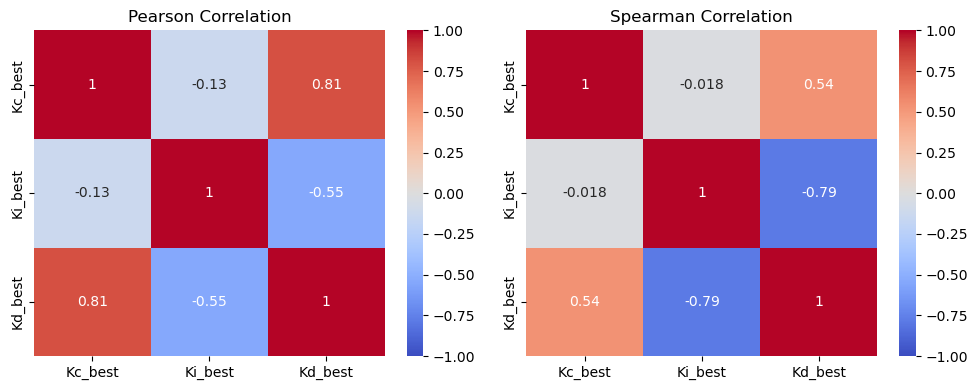

In [5]:
# Compute Pearson correlation matrix
pearson_corr = df_corr.corr(method='pearson')

# Compute Spearman correlation matrix
spearman_corr = df_corr.corr(method='spearman')

# Display correlation heatmaps
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson Correlation')

plt.subplot(1, 2, 2)
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation')

plt.tight_layout()
plt.show()

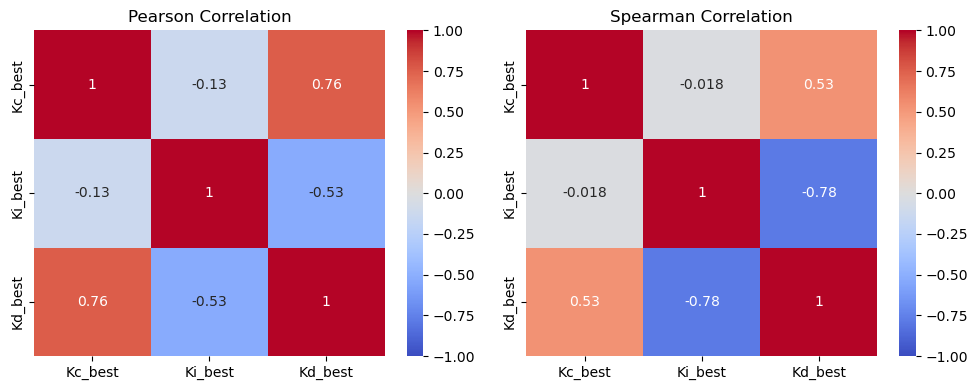

In [6]:
# Compute Pearson correlation matrix
pearson_corr = df1_corr.corr(method='pearson')

# Compute Spearman correlation matrix
spearman_corr = df1_corr.corr(method='spearman')

# Display correlation heatmaps
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson Correlation')

plt.subplot(1, 2, 2)
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation')

plt.tight_layout()
plt.show()

## Matern 1/2 kernel (exponential) worked the best for Kp, and constraining Gaussian noise to 2 helped for interpretabilitiy.

In [7]:
print(np.max(Y_kp) - np.min(Y_kp))
print((np.max(Y_kp) - np.min(Y_kp))**2 / 4)
print(np.max(Y_ki) - np.min(Y_ki))
print((np.max(Y_ki) - np.min(Y_ki))**2 / 4)
print(np.max(Y_kd) - np.min(Y_kd))
print((np.max(Y_kd) - np.min(Y_kd))**2 / 4, '\n')

print(np.max(Y1_kp) - np.min(Y1_kp))
print((np.max(Y1_kp) - np.min(Y1_kp))**2 / 4)
print(np.max(Y1_ki) - np.min(Y1_ki))
print((np.max(Y1_ki) - np.min(Y1_ki))**2 / 4)
print(np.max(Y1_kd) - np.min(Y1_kd))
print((np.max(Y1_kd) - np.min(Y1_kd))**2 / 4)

72.05325
1297.9177088906251
28.49911
203.04981769802504
31.406540000000003
246.59268869290005 

74.50487000000001
1387.7439134292254
28.49911
203.04981769802504
42.21653
445.55885131022495


In [ ]:
print(Ynew[:,0])

# Ready for running and re-testing with ARD.

In [19]:
# Initialize kernel and model
kp_kernel = GPy.kern.Exponential(input_dim=X.shape[1], ARD=True)
kp_model = GPy.models.GPRegression(X, Y_kp, kp_kernel)
ki_kernel = GPy.kern.Exponential(input_dim=X.shape[1], ARD=True)
ki_model = GPy.models.GPRegression(X, Y_ki, ki_kernel)
kd_kernel = GPy.kern.Exponential(input_dim=X.shape[1], ARD=True)
kd_model = GPy.models.GPRegression(X, Y_kd, kd_kernel)

# kp_model.Gaussian_noise.variance = (np.max(Y_kp) - np.min(Y_kp))/100
kp_model.Gaussian_noise.variance = 0.01
kp_model.Gaussian_noise.variance.fix()
# ki_model.Gaussian_noise.variance = (np.max(Y_ki) - np.min(Y_ki))/100
ki_model.Gaussian_noise.variance = 0.01
ki_model.Gaussian_noise.variance.fix()
# kd_model.Gaussian_noise.variance = (np.max(Y_kd) - np.min(Y_kd))/100
kd_model.Gaussian_noise.variance = 0.01
kd_model.Gaussian_noise.variance.fix()

# Optimize the model
kp_model.optimize_restarts(5, robust=True, messages=False)
ki_model.optimize_restarts(5, robust=True, messages=False)
kd_model.optimize_restarts(5, robust=True, messages=False)

print(kp_model)
print(ki_model)
print(kd_model)

Optimization restart 1/5, f = 3341.271127080205
Optimization restart 2/5, f = 3334.2860745995563
Optimization restart 3/5, f = 3324.054244516035
Optimization restart 4/5, f = 3313.1295743036376
Optimization restart 5/5, f = 3313.2321259076034
Optimization restart 1/5, f = 1044.2089611488163
Optimization restart 2/5, f = 1041.1568659988416
Optimization restart 3/5, f = 1039.9544780112622
Optimization restart 4/5, f = 1054.716360729664
Optimization restart 5/5, f = 1061.0947254119046
Optimization restart 1/5, f = 2388.988222153594
Optimization restart 2/5, f = 2390.7312206528077
Optimization restart 3/5, f = 2388.945907942854
Optimization restart 4/5, f = 2388.9177517762946
Optimization restart 5/5, f = 2379.087185798817

Name : GP regression
Objective : 3313.1295743036376
Number of Parameters : 6
Number of Optimization Parameters : 5
Updates : True
Parameters:
  GP_regression.           |             value  |  constraints  |  priors
  Exponential.variance     |  834.127021477103  |     

In [20]:
# Initialize kernel and model
# kp1_kernel = GPy.kern.Exponential(input_dim=X1.shape[1])
# kp1_model = GPy.models.GPRegression(X1, Y1_kp, kp1_kernel)
# ki1_kernel = GPy.kern.Exponential(input_dim=X1.shape[1])
# ki1_model = GPy.models.GPRegression(X1, Y1_ki, ki1_kernel)
# kd1_kernel = GPy.kern.Exponential(input_dim=X1.shape[1])
# kd1_model = GPy.models.GPRegression(X1, Y1_kd, kd1_kernel)

kp1_kernel = GPy.kern.Exponential(input_dim=X1.shape[1], ARD=True)
kp1_model = GPy.models.GPRegression(X1, Y1_kp, kp1_kernel)
ki1_kernel = GPy.kern.Exponential(input_dim=X1.shape[1], ARD=True)
ki1_model = GPy.models.GPRegression(X1, Y1_ki, ki1_kernel)
kd1_kernel = GPy.kern.Exponential(input_dim=X1.shape[1], ARD=True)
kd1_model = GPy.models.GPRegression(X1, Y1_kd, kd1_kernel)

# kp1_model.Gaussian_noise.variance = (np.max(Y1_kp) - np.min(Y1_kp))/100
kp1_model.Gaussian_noise.variance = 0.01
kp1_model.Gaussian_noise.variance.fix()
# ki1_model.Gaussian_noise.variance = (np.max(Y1_ki) - np.min(Y1_ki))/100
ki1_model.Gaussian_noise.variance = 0.01
ki1_model.Gaussian_noise.variance.fix()
# kd1_model.Gaussian_noise.variance = (np.max(Y1_kd) - np.min(Y1_kd))/100
kd1_model.Gaussian_noise.variance = 0.01
kd1_model.Gaussian_noise.variance.fix()

# Optimize the model
kp1_model.optimize_restarts(5, robust=True, messages=False)
ki1_model.optimize_restarts(5, robust=True, messages=False)
kd1_model.optimize_restarts(5, robust=True, messages=False)

print(kp1_model)
print(ki1_model)
print(kd1_model)

Optimization restart 1/5, f = 3337.6906804472824
Optimization restart 2/5, f = 3325.3682553256203
Optimization restart 3/5, f = 3346.026186003353
Optimization restart 4/5, f = 3334.6768937501965
Optimization restart 5/5, f = 3315.7871900255045
Optimization restart 1/5, f = 1038.0257907570342
Optimization restart 2/5, f = 1052.2885892028216
Optimization restart 3/5, f = 1052.3627427363142
Optimization restart 4/5, f = 1034.807075321533
Optimization restart 5/5, f = 1048.5372790926772
Optimization restart 1/5, f = 2389.7279984590486
Optimization restart 2/5, f = 2389.073307728855
Optimization restart 3/5, f = 2391.7896539450226
Optimization restart 4/5, f = 2393.9115838316834
Optimization restart 5/5, f = 2359.384656948891

Name : GP regression
Objective : 3315.7871900255045
Number of Parameters : 6
Number of Optimization Parameters : 5
Updates : True
Parameters:
  GP_regression.           |              value  |  constraints  |  priors
  Exponential.variance     |  836.2237101364504  | 

In [24]:
print('kp_model lengthscales:', kp_model.kern.lengthscale.values)
print('ki_model lengthscales:', ki_model.kern.lengthscale.values)
print('kd_model lengthscales:', kd_model.kern.lengthscale.values)
print('kp1_model lengthscales:', kp1_model.kern.lengthscale.values)
print('ki1_model lengthscales:', ki1_model.kern.lengthscale.values)
print('kd1_model lengthscales:', kd1_model.kern.lengthscale.values)

kp_model lengthscales: [3.88521493e+01 3.79570358e+01 1.17269640e+03 2.68585560e-01]
ki_model lengthscales: [2.33738402e+04 1.27692768e+03 3.10496353e+04 1.00427889e+01]
kd_model lengthscales: [7.45610652e+02 1.81822556e+02 5.05351261e+03 4.39773136e+00]
kp1_model lengthscales: [3.87969600e+01 3.82382170e+01 1.17901922e+03 2.69216261e-01]
ki1_model lengthscales: [4.23372324e+04 1.44167175e+03 3.02491264e+04 1.16412810e+01]
kd1_model lengthscales: [1.68731097e+02 4.97991949e+01 3.56066084e+03 1.31952463e+00]


In [22]:
Cai_ss123=10-2
F_ss123=5.7-3
Cac_ss123=300-20
Fc_ss123=0.3
temp_i = np.array([[Cai_ss123, F_ss123, Cac_ss123, Fc_ss123]])

print("Model withOUT initial point:")
Kp0_i, Kp0var = kp_model.predict(temp_i)
print(Kp0_i)
Ki0_i, Ki0var = ki_model.predict(temp_i)
print(Ki0_i)
Kd0_i, Kd0var = kd_model.predict(temp_i)
print(Kd0_i)

print("\nModel WITH initial point:")
Kp0_i, Kp0var = kp1_model.predict(temp_i)
print(Kp0_i)
Ki0_i, Ki0var = ki1_model.predict(temp_i)
print(Ki0_i)
Kd0_i, Kd0var = kd1_model.predict(temp_i)
print(Kd0_i)

Model withOUT initial point:
[[28.27791498]]
[[1.88828175]]
[[9.45596191]]

Model WITH initial point:
[[28.36714993]]
[[1.8875864]]
[[9.86074521]]


In [71]:
abc123, abc222 = kp_model.predict(np.array([[10, 5.7, 300, 0.3]]))
print(abc123)
print(abc222)
print(abc123[0])
print(abc123[0][0])

[[20.58384525]]
[[26.74743587]]
[20.58384525]
20.58384524683629


In [23]:
temp_iii = np.array([[10,5.7,300,0.3]])

Kp0_i, Kp0var = kp_model.predict(temp_iii)
Ki0_i, Ki0var = ki_model.predict(temp_iii)
Kd0_i, Kd0var = kd_model.predict(temp_iii)
print("Kp:", Kp0_i, '   Kp var:', Kp0var)
print("Ki:", Ki0_i, '   Ki var:', Ki0var)
print("Kd:", Kd0_i, '   Kd var:', Kd0var)

Kp0_i, Kp0var = kp1_model.predict(temp_iii)
Ki0_i, Ki0var = ki1_model.predict(temp_iii)
Kd0_i, Kd0var = kd1_model.predict(temp_iii)
print("Kp1:", Kp0_i, '   Kp1 var:', Kp0var)
print("Ki1:", Ki0_i, '   Ki1 var:', Ki0var)
print("Kd1:", Kd0_i, '   Kd1 var:', Kd0var)

Kp: [[20.58364601]]    Kp var: [[26.74813288]]
Ki: [[4.70501043]]    Ki var: [[0.29875786]]
Kd: [[6.09611075]]    Kd var: [[4.45253468]]
Kp1: [[18.31620207]]    Kp1 var: [[0.01999627]]
Ki1: [[4.58243639]]    Ki1 var: [[0.01964764]]
Kd1: [[5.09688037]]    Kd1 var: [[0.01997717]]


In [ ]:
### WITH ARD ###
# Cai_ss123=10-2
# F_ss123=5.7-3
# Cac_ss123=300-20
# Fc_ss123=0.3



# Exponential kernel
# Model withOUT initial point:
# [[28.27723297]]
# [[1.884916]]
# [[9.35901886]]

# Model WITH initial point:
# [[28.24911598]]
# [[1.87089056]]
# [[9.38262672]]



# Matern 3/2 kernel
# Model withOUT initial point:
# [[30.99944308]]
# [[1.86266678]]
# [[11.27930833]]

# Model WITH initial point:
# [[30.99250785]]
# [[1.86218797]]
# [[11.30002215]]



# Matern 5/2 kernel
# Model withOUT initial point:
# [[31.46652822]]
# [[2.00391583]]
# [[7.0567214]]

# Model WITH initial point:
# [[31.45992809]]
# [[2.0038806]]
# [[6.99835643]]



# RBF kernel
# Model withOUT initial point:
# [[32.23271453]]
# [[2.00674984]]
# [[5.12618323]]

# Model WITH initial point:
# [[32.22980466]]
# [[2.00674962]]
# [[4.96453352]]

In [30]:
from scipy.integrate import odeint
### From init_cond_06-11-25: 23.21586,6.41678,6.52398
# Define System and Time Evolution

def test_exp(Cai_ss=10,F_ss=5.7,Cac_ss=300,Fc_ss=0.3,Kp=18.31536,Ki=4.57784,Kd=5.09491):
    # Volume of tank 1 and tank 2 (m3)
    V = np.empty(2)
    V[0] = 5
    V[1] = 4

#     # Concentration of Initial Stream (kg/m3)
#     Cai_ss = 10

#     # Concentration of Correction Stream (kg/m3)
#     Cac_ss = 200

#     # Inlet Flowrate Initial Steady State (m3/min)
#     F_ss = 5.7

#     # Correction Stream Initial Steady State (m3/min)
#     Fc_ss = 0.3

    # Total flowrate (m3/min)
    Ftot = F_ss + Fc_ss

    # Simulation time
    num_sec = 5
    num_mins = 120
    t = np.linspace(0,num_mins,int(num_mins*(60/num_sec)+1)) # Total of two hours of simulation time, sampling every 5 seconds

    # PID controller parameter arrays
    Kp_arrC, Kp_arr0 = (np.zeros(len(t)) for _ in range(2))
    Ki_arrC, Ki_arr0 = (np.zeros(len(t)) for _ in range(2))
    Kd_arrC, Kd_arr0 = (np.zeros(len(t)) for _ in range(2))

    # Unit conversion for U and Fc
    Kv_ss = 0.01

    # Initial Concentration of Tank 1 and of Tank 2 (kg/m3)
    Ca1_ss = Ca2_ss = (F_ss * Cai_ss + Fc_ss * Cac_ss) / Ftot

    # Controller output steady state
    u_ss = Fc_ss/Kv_ss # For Kv = 0.01

    # Define vectors
    # Define vectors
    # Cai
    Cai = np.ones(len(t))*Cai_ss
    Cai[-(len(t)-100):] = Cai_ss + 3
    Cai[-(len(t)-500):] = Cai_ss - 3
    Cai[-(len(t)-900):] = Cai_ss + 3
    Cai[-(len(t)-1200):] = Cai_ss - 3

    # F
    F = np.ones(len(t))*F_ss
    F[-(len(t)-200):] = F_ss + 2
    F[-(len(t)-600):] = F_ss - 2
    F[-(len(t)-1100):] = F_ss

    # Cac
    Cac = np.ones(len(t))*Cac_ss
    Cac[-(len(t)-300):] = Cac_ss + 20
    Cac[-(len(t)-700):] = Cac_ss - 30
    Cac[-(len(t)-900):] = Cac_ss + 20
    Cac[-(len(t)-1200):] = Cac_ss - 30

    # setpoint
    sp = np.ones(len(t)) * Ca2_ss
    sp[-(len(t)-400):] = Ca2_ss - 2
    sp[-(len(t)-800):] = Ca2_ss + 2
    sp[-(len(t)-1000):] = Ca2_ss
    sp[-(len(t)-1350):] = Ca2_ss - 4

    # Measured Variables
    FcC, Fc0 = (np.ones(len(t)) * Fc_ss for _ in range(2))
    Ca1C, Ca10 = (np.ones(len(t)) * Ca1_ss for _ in range(2))
    Ca2C, Ca20 = (np.ones(len(t)) * Ca2_ss for _ in range(2))
    uC, u0 = (np.ones(len(t)) * u_ss for _ in range(2))

    # Declare vectors to pass
    xC = np.empty(3)
    xC[0] = Fc_ss
    xC[1] = Ca1_ss
    xC[2] = Ca2_ss

    x0 = np.empty(3)
    x0[0] = Fc_ss
    x0[1] = Ca1_ss
    x0[2] = Ca2_ss
    
    # Track error for testing purposes
    errorC = np.zeros(len(t))
    error0 = np.zeros(len(t))

    temp_i = np.array([[Cai_ss, F_ss, Cac_ss, Fc_ss]])

    Kp0_i, Kp0var = kp_model.predict(temp_i)
    Kp_arr0[0] = Kp0_i[0][0]
    Ki0_i, Ki0var = ki_model.predict(temp_i)
    Ki_arr0[0] = Ki0_i[0][0]
    Kd0_i, Kd0var = kd_model.predict(temp_i)
    Kd_arr0[0] = Kd0_i[0][0]

    # create PID controller
    # op = op_bias + Kc * e + Ki * ei + Kd * ed
    #      with ei = error integral
    #      with ed = error derivative

    u_bias = u_ss
    umin = 0
    umax = 50

    pidC = PID(Kp,Ki,Ki,sample_time=None,output_limits=(umin-u_bias,umax-u_bias))
    pid0 = PID(Kp0_i[0][0],Ki0_i[0][0],Kd0_i[0][0],sample_time=None,output_limits=(umin-u_bias,umax-u_bias))

    # Simulate tank system ********
    for i in range(len(t)-1):
        ### PID control - update all 8 controller setpoints
        pidC.setpoint=sp[i]
        pid0.setpoint=sp[i]

        temp0 = np.array([[Cai[i], F[i], Cac[i], Fc0[i]]])

        Kp0, Kp0var = kp_model.predict(temp0)
        Kp_arr0[i] = Kp0[0][0]
        Ki0, Ki0var = ki_model.predict(temp0)
        Ki_arr0[i] = Ki0[0][0]
        Kd0, Kd0var = kd_model.predict(temp0)
        Kd_arr0[i] = Kd0[0][0]

        ### Adjust all PID parameters, making sure to un-normalize the ANNs that were trained on normalized data.
        pid0.Kp = Kp0[0][0]
        pid0.Ki = Ki0[0][0]
        pid0.Kd = Kd0[0][0]

        ### Values shared across all systems
        ts = [t[i],t[i+1]]

        ### Update all systems in time
        FtotC = F[i] + FcC[i]
        uC[i+1] = pidC(Ca2C[i], t[i+1]-t[i]) + u_bias
        yC = odeint(two_tanks,xC,ts,args=(uC[i+1],Cai[i],F[i],Cac[i],FtotC,V))
        FcC[i+1] = round(yC[-1][0], 5)   
        Ca1C[i+1] = round(yC[-1][1], 5)
        Ca2C[i+1] = round(yC[-1][2], 5)
        xC[0] = FcC[i+1]
        xC[1] = Ca1C[i+1]
        xC[2] = Ca2C[i+1]

        Ftot0 = F[i] + Fc0[i]
        u0[i+1] = pid0(Ca20[i], t[i+1]-t[i]) + u_bias
        y0 = odeint(two_tanks,x0,ts,args=(u0[i+1],Cai[i],F[i],Cac[i],Ftot0,V))
        Fc0[i+1] = round(y0[-1][0], 5)   
        Ca10[i+1] = round(y0[-1][1], 5)
        Ca20[i+1] = round(y0[-1][2], 5)
        x0[0] = Fc0[i+1]
        x0[1] = Ca10[i+1]
        x0[2] = Ca20[i+1]
        
        # Track error
        errorC[i] = sp[i] - Ca2C[i]
        error0[i] = sp[i] - Ca20[i]

    ### Need to deal with the final conditions
    temp_0 = np.array([[Cai[len(t)-1], F[len(t)-1], Cac[len(t)-1], Fc0[len(t)-1]]])
    Kp0_0, Kp0var = kp_model.predict(temp_0)
    Kp_arr0[-1] = Kp0_0[0][0]
    Ki0_0, Ki0var = ki_model.predict(temp_0)
    Ki_arr0[-1] = Ki0_0[0][0]
    Kd0_0, Kd0var = kd_model.predict(temp_0)
    Kd_arr0[-1] = Kd0_0[0][0]
    
    # Plot the results
    plt.figure(figsize=(10,20))  
    plt.subplot(10,1,1)
    plt.plot(t,Cai,'b-',linewidth=3)
    plt.ylabel('Cai (kg/m3)')
    plt.plot([t[0],t[-1]],[Cai_ss,Cai_ss],'k-',linewidth=1)
    plt.xlim(0, t[-1])
    plt.ylim(4.8, 15.2)
    plt.legend(['Cai','Cai initial'],loc='best')

    plt.subplot(10,1,2)
    plt.plot(t[0:len(t)],F[0:len(t)],'r-',linewidth=3)
    plt.plot([t[0],t[-1]],[F_ss,F_ss],'k-',linewidth=1)
    plt.ylabel('F (m3/min)')
    plt.xlim(0, t[-1])
    plt.ylim(0.48, 10.2)
    plt.legend(['F','F initial'],loc='best')

    plt.subplot(10,1,3)
    plt.plot(t[0:len(t)],Cac[0:len(t)],'b-',linewidth=3)
    plt.ylabel('Cac (kg/m3)')
    plt.xlabel('Time (min)')
    plt.plot([t[0],t[-1]],[Cac_ss,Cac_ss],'k-',linewidth=1)
    plt.xlim(0, t[-1])
    plt.ylim(198, 402)
    plt.legend(['Cac','Cac initial'],loc='best')

    plt.subplot(10,1,4)
    plt.plot(t[0:len(t)],FcC[0:len(t)],'r-',linewidth=3)
    plt.plot([t[0],t[-1]],[Fc_ss,Fc_ss],'k-',linewidth=1)
    plt.ylabel('Fc, PID Control (m3/min)')
    plt.xlim(0, t[-1])
    plt.ylim(-0.02, 0.52)
    plt.legend(['Fc','Fc initial'],loc='best')

    plt.subplot(10,1,5)
    plt.plot(t[0:len(t)],Ca2C[0:len(t)],'b-',linewidth=3)
    plt.plot(t[0:len(t)],sp[0:len(t)],'k--',linewidth=3)
    plt.ylabel('Ca2, PID Control (kg/m3)')
    plt.plot([t[0],t[-1]],[Ca2_ss,Ca2_ss],'k-',linewidth=1)
    plt.xlim(0, t[-1])
    plt.ylim(4.8, 28.8)
    plt.legend(['Ca2','Ca2 initial'],loc='best')

    plt.subplot(10,1,6)
    plt.plot(t[0:len(t)],Fc0[0:len(t)],'r-',linewidth=3)
    plt.plot([t[0],t[-1]],[Fc_ss,Fc_ss],'k-',linewidth=1)
    plt.ylabel('Fc, PID 0 (m3/min)')
    plt.xlim(0, t[-1])
    plt.ylim(-0.02, 0.52)
    plt.legend(['Fc','Fc initial'],loc='best')

    plt.subplot(10,1,7)
    plt.plot(t[0:len(t)],Ca20[0:len(t)],'b-',linewidth=3)
    plt.plot(t[0:len(t)],sp[0:len(t)],'k--',linewidth=3)
    plt.ylabel('Ca2, PID 0 (kg/m3)')
    plt.plot([t[0],t[-1]],[Ca2_ss,Ca2_ss],'k-',linewidth=1)
    plt.xlim(0, t[-1])
    plt.ylim(4.8, 28.8)
    plt.legend(['Ca2','Ca2 initial'],loc='best')

    plt.subplot(10,1,8)
    plt.plot(t[0:len(t)],Kp_arr0[0:len(t)],'g-',linewidth=3)
    # plt.plot(t[0:len(t)],sp[0:len(t)],'k--',linewidth=3)
    plt.ylabel('Kp, PID 0 (kg/m3)')
    plt.plot([t[0],t[-1]],[Kp,Kp],'k-',linewidth=1)
    plt.xlim(0, t[-1])
    plt.ylim(np.min(Kp_arr0)-0.2, np.max(Kp_arr0)+0.2)
    plt.legend(['Kp','Kp initial'],loc='best')

    plt.subplot(10,1,9)
    plt.plot(t[0:len(t)],Ki_arr0[0:len(t)],'g-',linewidth=3)
    # plt.plot(t[0:len(t)],sp[0:len(t)],'k--',linewidth=3)
    plt.ylabel('Ki, PID 0 (kg/m3)')
    plt.plot([t[0],t[-1]],[Ki,Ki],'k-',linewidth=1)
    plt.xlim(0, t[-1])
    plt.ylim(np.min(Ki_arr0)-0.2, np.max(Ki_arr0)+0.2)
    plt.legend(['Ki','Ki initial'],loc='best')

    plt.subplot(10,1,10)
    plt.plot(t[0:len(t)],Kd_arr0[0:len(t)],'g-',linewidth=3)
    # plt.plot(t[0:len(t)],sp[0:len(t)],'k--',linewidth=3)
    plt.ylabel('Kd, PID 0 (kg/m3)')
    plt.plot([t[0],t[-1]],[Kd,Kd],'k-',linewidth=1)
    plt.xlim(0, t[-1])
    plt.ylim(np.min(Kd_arr0)-0.2, np.max(Kd_arr0)+0.2)
    plt.legend(['Kd','Kd initial'],loc='best')
    
    print('sum errorC:', sum(errorC))
    print('sum error0:', sum(error0))
    print('sum abs errorC:', sum(abs(errorC)))
    print('sum abs error0:', sum(abs(error0)))
    
from scipy.integrate import odeint

# Define System and Time Evolution
def test_exp1(Cai_ss=10,F_ss=5.7,Cac_ss=300,Fc_ss=0.3,Kp=18.31536,Ki=4.57784,Kd=5.09491):
    # Volume of tank 1 and tank 2 (m3)
    V = np.empty(2)
    V[0] = 5
    V[1] = 4

#     # Concentration of Initial Stream (kg/m3)
#     Cai_ss = 10

#     # Concentration of Correction Stream (kg/m3)
#     Cac_ss = 200

#     # Inlet Flowrate Initial Steady State (m3/min)
#     F_ss = 5.7

#     # Correction Stream Initial Steady State (m3/min)
#     Fc_ss = 0.3

    # Total flowrate (m3/min)
    Ftot = F_ss + Fc_ss

    # Simulation time
    num_sec = 5
    num_mins = 120
    t = np.linspace(0,num_mins,int(num_mins*(60/num_sec)+1)) # Total of two hours of simulation time, sampling every 5 seconds

    # PID controller parameter arrays
    Kp_arrC, Kp_arr0 = (np.zeros(len(t)) for _ in range(2))
    Ki_arrC, Ki_arr0 = (np.zeros(len(t)) for _ in range(2))
    Kd_arrC, Kd_arr0 = (np.zeros(len(t)) for _ in range(2))

    # Unit conversion for U and Fc
    Kv_ss = 0.01

    # Initial Concentration of Tank 1 and of Tank 2 (kg/m3)
    Ca1_ss = Ca2_ss = (F_ss * Cai_ss + Fc_ss * Cac_ss) / Ftot

    # Controller output steady state
    u_ss = Fc_ss/Kv_ss # For Kv = 0.01

    # Define vectors
    # Define vectors
    # Cai
#     Cai = np.ones(len(t))*Cai_ss
#     Cai[-(len(t)-100):] = Cai_ss - 2
#     Cai[-(len(t)-500):] = Cai_ss + 2
#     Cai[-(len(t)-900):] = Cai_ss - 2
#     Cai[-(len(t)-1200):] = Cai_ss + 2

#     # F
#     F = np.ones(len(t))*F_ss
#     F[-(len(t)-200):] = F_ss - 3
#     F[-(len(t)-600):] = F_ss + 3
#     F[-(len(t)-1100):] = F_ss

#     # Cac
#     Cac = np.ones(len(t))*Cac_ss
#     Cac[-(len(t)-300):] = Cac_ss - 20
#     Cac[-(len(t)-700):] = Cac_ss + 20
#     Cac[-(len(t)-900):] = Cac_ss + 60
#     Cac[-(len(t)-1200):] = Cac_ss - 20

#     # setpoint
#     sp = np.ones(len(t)) * Ca2_ss
#     sp[-(len(t)-400):] = Ca2_ss - 2
#     sp[-(len(t)-800):] = Ca2_ss + 2
#     sp[-(len(t)-1000):] = Ca2_ss
#     sp[-(len(t)-1350):] = Ca2_ss - 4

    # Cai
    Cai = np.ones(len(t))*Cai_ss
    Cai[-(len(t)-100):] = Cai_ss + 3
    Cai[-(len(t)-500):] = Cai_ss - 3
    Cai[-(len(t)-900):] = Cai_ss + 3
    Cai[-(len(t)-1200):] = Cai_ss - 3

    # F
    F = np.ones(len(t))*F_ss
    F[-(len(t)-200):] = F_ss + 2
    F[-(len(t)-600):] = F_ss - 2
    F[-(len(t)-1100):] = F_ss

    # Cac
    Cac = np.ones(len(t))*Cac_ss
    Cac[-(len(t)-300):] = Cac_ss + 20
    Cac[-(len(t)-700):] = Cac_ss - 30
    Cac[-(len(t)-900):] = Cac_ss + 20
    Cac[-(len(t)-1200):] = Cac_ss - 30

    # setpoint
    sp = np.ones(len(t)) * Ca2_ss
    sp[-(len(t)-400):] = Ca2_ss - 2
    sp[-(len(t)-800):] = Ca2_ss + 2
    sp[-(len(t)-1000):] = Ca2_ss
    sp[-(len(t)-1350):] = Ca2_ss - 4

    # Measured Variables
    FcC, Fc0 = (np.ones(len(t)) * Fc_ss for _ in range(2))
    Ca1C, Ca10 = (np.ones(len(t)) * Ca1_ss for _ in range(2))
    Ca2C, Ca20 = (np.ones(len(t)) * Ca2_ss for _ in range(2))
    uC, u0 = (np.ones(len(t)) * u_ss for _ in range(2))

    # Declare vectors to pass
    xC = np.empty(3)
    xC[0] = Fc_ss
    xC[1] = Ca1_ss
    xC[2] = Ca2_ss

    x0 = np.empty(3)
    x0[0] = Fc_ss
    x0[1] = Ca1_ss
    x0[2] = Ca2_ss
    
    # Track error for testing purposes
    errorC = np.zeros(len(t))
    error0 = np.zeros(len(t))

    temp_i = np.array([[Cai_ss, F_ss, Cac_ss, Fc_ss]])

    Kp0_i, Kp0var = kp1_model.predict(temp_i)
    Kp_arr0[0] = Kp0_i[0][0]
    Ki0_i, Ki0var = ki1_model.predict(temp_i)
    Ki_arr0[0] = Ki0_i[0][0]
    Kd0_i, Kd0var = kd1_model.predict(temp_i)
    Kd_arr0[0] = Kd0_i[0][0]

    # create PID controller
    # op = op_bias + Kc * e + Ki * ei + Kd * ed
    #      with ei = error integral
    #      with ed = error derivative

    u_bias = u_ss
    umin = 0
    umax = 50

    pidC = PID(Kp,Ki,Ki,sample_time=None,output_limits=(umin-u_bias,umax-u_bias))
    pid0 = PID(Kp0_i[0][0],Ki0_i[0][0],Kd0_i[0][0],sample_time=None,output_limits=(umin-u_bias,umax-u_bias))

    # Simulate tank system ********
    for i in range(len(t)-1):
        ### PID control - update all 8 controller setpoints
        pidC.setpoint=sp[i]
        pid0.setpoint=sp[i]

        temp0 = np.array([[Cai[i], F[i], Cac[i], Fc0[i]]])

        Kp0, Kp0var = kp1_model.predict(temp0)
        Kp_arr0[i] = Kp0[0][0]
        Ki0, Ki0var = ki1_model.predict(temp0)
        Ki_arr0[i] = Ki0[0][0]
        Kd0, Kd0var = kd1_model.predict(temp0)
        Kd_arr0[i] = Kd0[0][0]

        ### Adjust all PID parameters, making sure to un-normalize the ANNs that were trained on normalized data.
        pid0.Kp = Kp0[0][0]
        pid0.Ki = Ki0[0][0]
        pid0.Kd = Kd0[0][0]

        ### Values shared across all systems
        ts = [t[i],t[i+1]]

        ### Update all systems in time
        FtotC = F[i] + FcC[i]
        uC[i+1] = pidC(Ca2C[i], t[i+1]-t[i]) + u_bias
        yC = odeint(two_tanks,xC,ts,args=(uC[i+1],Cai[i],F[i],Cac[i],FtotC,V))
        FcC[i+1] = round(yC[-1][0], 5)   
        Ca1C[i+1] = round(yC[-1][1], 5)
        Ca2C[i+1] = round(yC[-1][2], 5)
        xC[0] = FcC[i+1]
        xC[1] = Ca1C[i+1]
        xC[2] = Ca2C[i+1]

        Ftot0 = F[i] + Fc0[i]
        u0[i+1] = pid0(Ca20[i], t[i+1]-t[i]) + u_bias
        y0 = odeint(two_tanks,x0,ts,args=(u0[i+1],Cai[i],F[i],Cac[i],Ftot0,V))
        Fc0[i+1] = round(y0[-1][0], 5)   
        Ca10[i+1] = round(y0[-1][1], 5)
        Ca20[i+1] = round(y0[-1][2], 5)
        x0[0] = Fc0[i+1]
        x0[1] = Ca10[i+1]
        x0[2] = Ca20[i+1]
        
        # Track error
        errorC[i] = sp[i] - Ca2C[i]
        error0[i] = sp[i] - Ca20[i]

    ### Need to deal with the final conditions
    temp_0 = np.array([[Cai[len(t)-1], F[len(t)-1], Cac[len(t)-1], Fc0[len(t)-1]]])
    Kp0_0, Kp0var = kp1_model.predict(temp_0)
    Kp_arr0[-1] = Kp0_0[0][0]
    Ki0_0, Ki0var = ki1_model.predict(temp_0)
    Ki_arr0[-1] = Ki0_0[0][0]
    Kd0_0, Kd0var = kd1_model.predict(temp_0)
    Kd_arr0[-1] = Kd0_0[0][0]
    
    # Plot the results
    plt.figure(figsize=(10,20))  
    plt.subplot(10,1,1)
    plt.plot(t,Cai,'b-',linewidth=3)
    plt.ylabel('Cai (kg/m3)')
    plt.plot([t[0],t[-1]],[Cai_ss,Cai_ss],'k-',linewidth=1)
    plt.xlim(0, t[-1])
    plt.ylim(4.8, 15.2)
    plt.legend(['Cai','Cai initial'],loc='best')

    plt.subplot(10,1,2)
    plt.plot(t[0:len(t)],F[0:len(t)],'r-',linewidth=3)
    plt.plot([t[0],t[-1]],[F_ss,F_ss],'k-',linewidth=1)
    plt.ylabel('F (m3/min)')
    plt.xlim(0, t[-1])
    plt.ylim(0.48, 10.2)
    plt.legend(['F','F initial'],loc='best')

    plt.subplot(10,1,3)
    plt.plot(t[0:len(t)],Cac[0:len(t)],'b-',linewidth=3)
    plt.ylabel('Cac (kg/m3)')
    plt.xlabel('Time (min)')
    plt.plot([t[0],t[-1]],[Cac_ss,Cac_ss],'k-',linewidth=1)
    plt.xlim(0, t[-1])
    plt.ylim(198, 402)
    plt.legend(['Cac','Cac initial'],loc='best')

    plt.subplot(10,1,4)
    plt.plot(t[0:len(t)],FcC[0:len(t)],'r-',linewidth=3)
    plt.plot([t[0],t[-1]],[Fc_ss,Fc_ss],'k-',linewidth=1)
    plt.ylabel('Fc, PID Control (m3/min)')
    plt.xlim(0, t[-1])
    plt.ylim(-0.02, 0.52)
    plt.legend(['Fc','Fc initial'],loc='best')

    plt.subplot(10,1,5)
    plt.plot(t[0:len(t)],Ca2C[0:len(t)],'b-',linewidth=3)
    plt.plot(t[0:len(t)],sp[0:len(t)],'k--',linewidth=3)
    plt.ylabel('Ca2, PID Control (kg/m3)')
    plt.plot([t[0],t[-1]],[Ca2_ss,Ca2_ss],'k-',linewidth=1)
    plt.xlim(0, t[-1])
    plt.ylim(4.8, 28.8)
    plt.legend(['Ca2','Ca2 initial'],loc='best')

    plt.subplot(10,1,6)
    plt.plot(t[0:len(t)],Fc0[0:len(t)],'r-',linewidth=3)
    plt.plot([t[0],t[-1]],[Fc_ss,Fc_ss],'k-',linewidth=1)
    plt.ylabel('Fc, PID 0 (m3/min)')
    plt.xlim(0, t[-1])
    plt.ylim(-0.02, 0.52)
    plt.legend(['Fc','Fc initial'],loc='best')

    plt.subplot(10,1,7)
    plt.plot(t[0:len(t)],Ca20[0:len(t)],'b-',linewidth=3)
    plt.plot(t[0:len(t)],sp[0:len(t)],'k--',linewidth=3)
    plt.ylabel('Ca2, PID 0 (kg/m3)')
    plt.plot([t[0],t[-1]],[Ca2_ss,Ca2_ss],'k-',linewidth=1)
    plt.xlim(0, t[-1])
    plt.ylim(4.8, 28.8)
    plt.legend(['Ca2','Ca2 initial'],loc='best')

    plt.subplot(10,1,8)
    plt.plot(t[0:len(t)],Kp_arr0[0:len(t)],'g-',linewidth=3)
    # plt.plot(t[0:len(t)],sp[0:len(t)],'k--',linewidth=3)
    plt.ylabel('Kp, PID 0 (kg/m3)')
    plt.plot([t[0],t[-1]],[Kp,Kp],'k-',linewidth=1)
    plt.xlim(0, t[-1])
    plt.ylim(np.min(Kp_arr0)-0.2, np.max(Kp_arr0)+0.2)
    plt.legend(['Kp','Kp initial'],loc='best')

    plt.subplot(10,1,9)
    plt.plot(t[0:len(t)],Ki_arr0[0:len(t)],'g-',linewidth=3)
    # plt.plot(t[0:len(t)],sp[0:len(t)],'k--',linewidth=3)
    plt.ylabel('Ki, PID 0 (kg/m3)')
    plt.plot([t[0],t[-1]],[Ki,Ki],'k-',linewidth=1)
    plt.xlim(0, t[-1])
    plt.ylim(np.min(Ki_arr0)-0.2, np.max(Ki_arr0)+0.2)
    plt.legend(['Ki','Ki initial'],loc='best')

    plt.subplot(10,1,10)
    plt.plot(t[0:len(t)],Kd_arr0[0:len(t)],'g-',linewidth=3)
    # plt.plot(t[0:len(t)],sp[0:len(t)],'k--',linewidth=3)
    plt.ylabel('Kd, PID 0 (kg/m3)')
    plt.plot([t[0],t[-1]],[Kd,Kd],'k-',linewidth=1)
    plt.xlim(0, t[-1])
    plt.ylim(np.min(Kd_arr0)-0.2, np.max(Kd_arr0)+0.2)
    plt.legend(['Kd','Kd initial'],loc='best')
    
    print('sum errorC:', sum(errorC))
    print('sum error1:', sum(error0))
    print('sum abs errorC:', sum(abs(errorC)))
    print('sum abs error1:', sum(abs(error0)))

sum errorC: 1.4601000000000255
sum error0: -38.46569000000005
sum abs errorC: 331.1679999999998
sum abs error0: 342.20652999999953


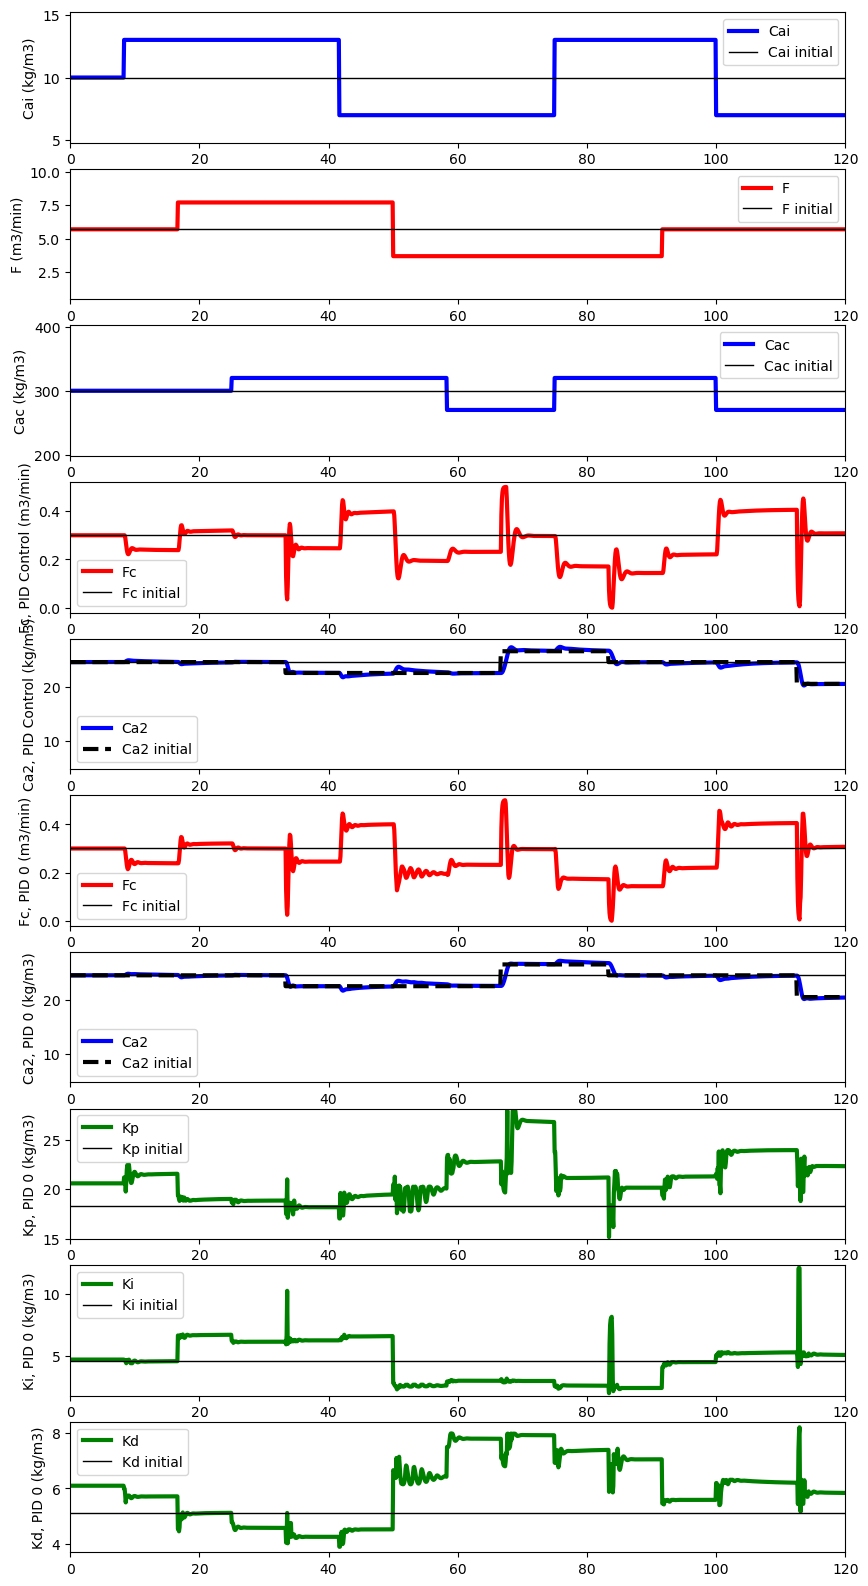

In [26]:
test_exp()

sum errorC: 1.4601000000000255
sum error1: -43.01087000000009
sum abs errorC: 331.1679999999998
sum abs error1: 341.89855000000017


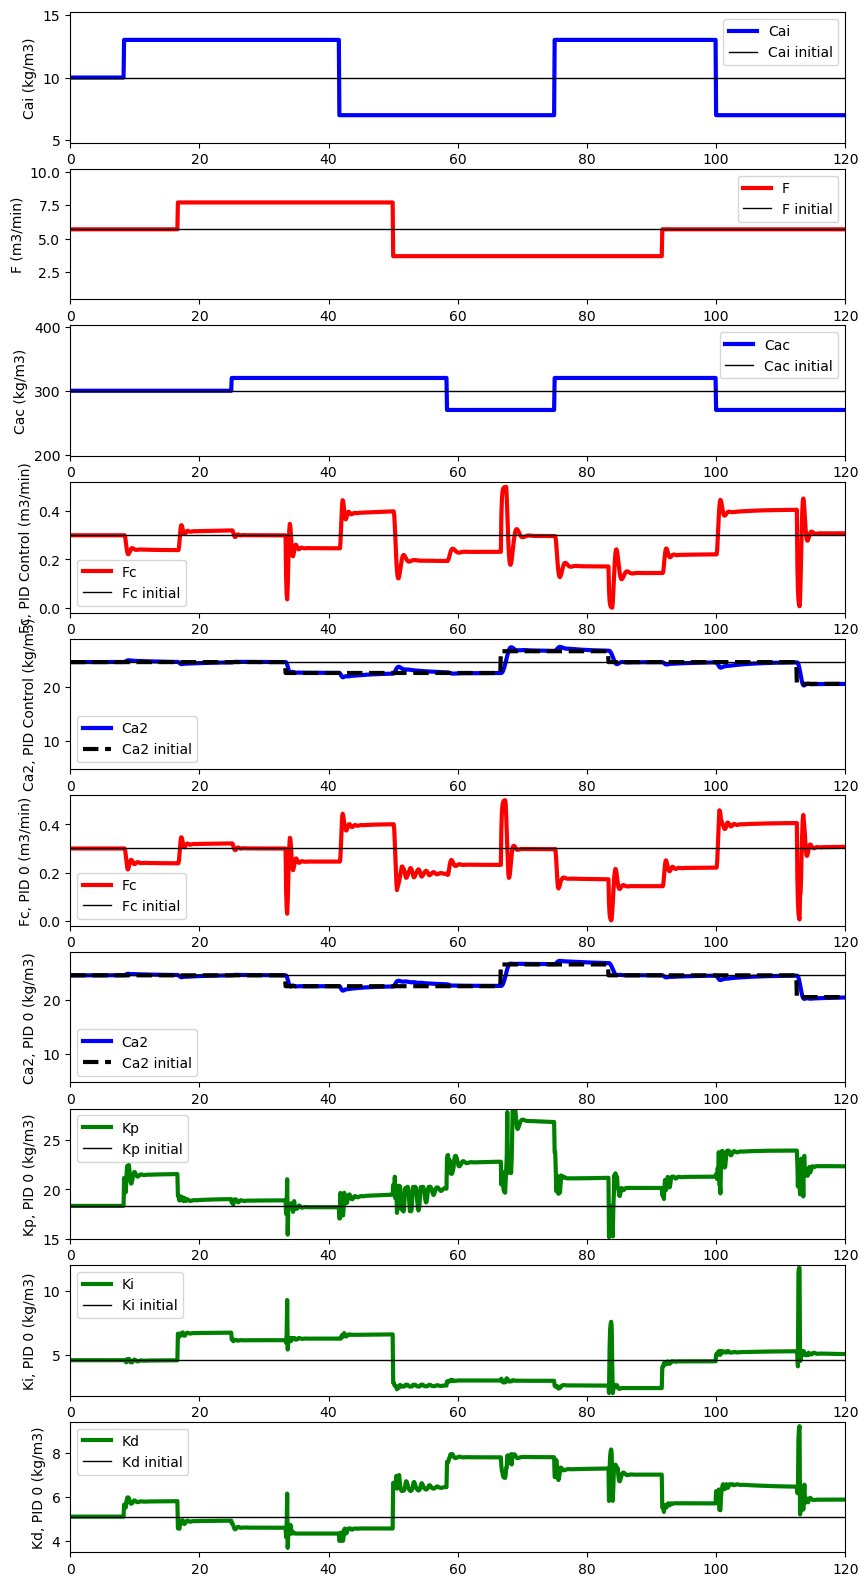

In [31]:
test_exp1()

In [31]:
import os
testtrue = os.path.isfile('bo_tt_NEWGENdatasetPLUSTESTPOINT_05-23-25.csv')
testtrue

True

In [34]:
### Testing kernels for GPs to predict PID parameters.
### Static PID did better on over half of the trials. 
for cnt in range(4):
    if cnt == 0:
        # filename = 'twotanks_test/test_GP_controller_errors_exponential_kernel_ARD.csv'
        filename = 'twotanks_test/test_GP1_CORRECTDATA_errors_exponential_kernel_ARD.csv'
        # Initialize kernel and model
#         kp_kernel = GPy.kern.Exponential(input_dim=X.shape[1], ARD=True)
#         kp_model = GPy.models.GPRegression(X, Y_kp, kp_kernel)
#         ki_kernel = GPy.kern.Exponential(input_dim=X.shape[1], ARD=True)
#         ki_model = GPy.models.GPRegression(X, Y_ki, ki_kernel)
#         kd_kernel = GPy.kern.Exponential(input_dim=X.shape[1], ARD=True)
#         kd_model = GPy.models.GPRegression(X, Y_kd, kd_kernel)
        
        kp1_kernel = GPy.kern.Exponential(input_dim=X1.shape[1], ARD=True)
        kp1_model = GPy.models.GPRegression(X1, Y1_kp, kp1_kernel)
        ki1_kernel = GPy.kern.Exponential(input_dim=X1.shape[1], ARD=True)
        ki1_model = GPy.models.GPRegression(X1, Y1_ki, ki1_kernel)
        kd1_kernel = GPy.kern.Exponential(input_dim=X1.shape[1], ARD=True)
        kd1_model = GPy.models.GPRegression(X1, Y1_kd, kd1_kernel)
        
        # kp_model.Gaussian_noise.variance = (np.max(Y_kp) - np.min(Y_kp))/100
#         kp_model.Gaussian_noise.variance = 0.01
#         kp_model.Gaussian_noise.variance.fix()
#         # ki_model.Gaussian_noise.variance = (np.max(Y_ki) - np.min(Y_ki))/100
#         ki_model.Gaussian_noise.variance = 0.01
#         ki_model.Gaussian_noise.variance.fix()
#         # kd_model.Gaussian_noise.variance = (np.max(Y_kd) - np.min(Y_kd))/100
#         kd_model.Gaussian_noise.variance = 0.01
#         kd_model.Gaussian_noise.variance.fix()

#         # Optimize the model
#         kp_model.optimize_restarts(5, robust=True, messages=False)
#         ki_model.optimize_restarts(5, robust=True, messages=False)
#         kd_model.optimize_restarts(5, robust=True, messages=False)
        
        # kp1_model.Gaussian_noise.variance = (np.max(Y1_kp) - np.min(Y1_kp))/100
        kp1_model.Gaussian_noise.variance = 0.01
        kp1_model.Gaussian_noise.variance.fix()
        # ki1_model.Gaussian_noise.variance = (np.max(Y1_ki) - np.min(Y1_ki))/100
        ki1_model.Gaussian_noise.variance = 0.01
        ki1_model.Gaussian_noise.variance.fix()
        # kd1_model.Gaussian_noise.variance = (np.max(Y1_kd) - np.min(Y1_kd))/100
        kd1_model.Gaussian_noise.variance = 0.01
        kd1_model.Gaussian_noise.variance.fix()

        # Optimize the model
        kp1_model.optimize_restarts(5, robust=True, messages=False)
        ki1_model.optimize_restarts(5, robust=True, messages=False)
        kd1_model.optimize_restarts(5, robust=True, messages=False)
        
    elif cnt == 1:
        # filename = 'twotanks_test/test_GP_controller_errors_matern32_kernel_ARD.csv'
        filename = 'twotanks_test/test_GP1_CORRECTDATA_errors_matern32_kernel_ARD.csv'
        # Initialize kernel and model
#         kp_kernel = GPy.kern.Matern32(input_dim=X.shape[1], ARD=True)
#         kp_model = GPy.models.GPRegression(X, Y_kp, kp_kernel)
#         ki_kernel = GPy.kern.Matern32(input_dim=X.shape[1], ARD=True)
#         ki_model = GPy.models.GPRegression(X, Y_ki, ki_kernel)
#         kd_kernel = GPy.kern.Matern32(input_dim=X.shape[1], ARD=True)
#         kd_model = GPy.models.GPRegression(X, Y_kd, kd_kernel)
        
        kp1_kernel = GPy.kern.Matern32(input_dim=X1.shape[1], ARD=True)
        kp1_model = GPy.models.GPRegression(X1, Y1_kp, kp1_kernel)
        ki1_kernel = GPy.kern.Matern32(input_dim=X1.shape[1], ARD=True)
        ki1_model = GPy.models.GPRegression(X1, Y1_ki, ki1_kernel)
        kd1_kernel = GPy.kern.Matern32(input_dim=X1.shape[1], ARD=True)
        kd1_model = GPy.models.GPRegression(X1, Y1_kd, kd1_kernel)
        
#         # kp_model.Gaussian_noise.variance = (np.max(Y_kp) - np.min(Y_kp))/100
#         kp_model.Gaussian_noise.variance = 0.01
#         kp_model.Gaussian_noise.variance.fix()
#         # ki_model.Gaussian_noise.variance = (np.max(Y_ki) - np.min(Y_ki))/100
#         ki_model.Gaussian_noise.variance = 0.01
#         ki_model.Gaussian_noise.variance.fix()
#         # kd_model.Gaussian_noise.variance = (np.max(Y_kd) - np.min(Y_kd))/100
#         kd_model.Gaussian_noise.variance = 0.01
#         kd_model.Gaussian_noise.variance.fix()

#         # Optimize the model
#         kp_model.optimize_restarts(5, robust=True, messages=False)
#         ki_model.optimize_restarts(5, robust=True, messages=False)
#         kd_model.optimize_restarts(5, robust=True, messages=False)
        
        # kp1_model.Gaussian_noise.variance = (np.max(Y1_kp) - np.min(Y1_kp))/100
        kp1_model.Gaussian_noise.variance = 0.01
        kp1_model.Gaussian_noise.variance.fix()
        # ki1_model.Gaussian_noise.variance = (np.max(Y1_ki) - np.min(Y1_ki))/100
        ki1_model.Gaussian_noise.variance = 0.01
        ki1_model.Gaussian_noise.variance.fix()
        # kd1_model.Gaussian_noise.variance = (np.max(Y1_kd) - np.min(Y1_kd))/100
        kd1_model.Gaussian_noise.variance = 0.01
        kd1_model.Gaussian_noise.variance.fix()

        # Optimize the model
        kp1_model.optimize_restarts(5, robust=True, messages=False)
        ki1_model.optimize_restarts(5, robust=True, messages=False)
        kd1_model.optimize_restarts(5, robust=True, messages=False)
        
    elif cnt == 2:
        # filename = 'twotanks_test/test_GP_controller_errors_matern52_kernel_ARD.csv'
        filename = 'twotanks_test/test_GP1_CORRECTDATA_errors_matern52_kernel_ARD.csv'
        # Initialize kernel and model
#         kp_kernel = GPy.kern.Matern52(input_dim=X.shape[1], ARD=True)
#         kp_model = GPy.models.GPRegression(X, Y_kp, kp_kernel)
#         ki_kernel = GPy.kern.Matern52(input_dim=X.shape[1], ARD=True)
#         ki_model = GPy.models.GPRegression(X, Y_ki, ki_kernel)
#         kd_kernel = GPy.kern.Matern52(input_dim=X.shape[1], ARD=True)
#         kd_model = GPy.models.GPRegression(X, Y_kd, kd_kernel)
        
        kp1_kernel = GPy.kern.Matern52(input_dim=X1.shape[1], ARD=True)
        kp1_model = GPy.models.GPRegression(X1, Y1_kp, kp1_kernel)
        ki1_kernel = GPy.kern.Matern52(input_dim=X1.shape[1], ARD=True)
        ki1_model = GPy.models.GPRegression(X1, Y1_ki, ki1_kernel)
        kd1_kernel = GPy.kern.Matern52(input_dim=X1.shape[1], ARD=True)
        kd1_model = GPy.models.GPRegression(X1, Y1_kd, kd1_kernel)
        
#         # kp_model.Gaussian_noise.variance = (np.max(Y_kp) - np.min(Y_kp))/100
#         kp_model.Gaussian_noise.variance = 0.01
#         kp_model.Gaussian_noise.variance.fix()
#         # ki_model.Gaussian_noise.variance = (np.max(Y_ki) - np.min(Y_ki))/100
#         ki_model.Gaussian_noise.variance = 0.01
#         ki_model.Gaussian_noise.variance.fix()
#         # kd_model.Gaussian_noise.variance = (np.max(Y_kd) - np.min(Y_kd))/100
#         kd_model.Gaussian_noise.variance = 0.01
#         kd_model.Gaussian_noise.variance.fix()

#         # Optimize the model
#         kp_model.optimize_restarts(5, robust=True, messages=False)
#         ki_model.optimize_restarts(5, robust=True, messages=False)
#         kd_model.optimize_restarts(5, robust=True, messages=False)
        
        # kp1_model.Gaussian_noise.variance = (np.max(Y1_kp) - np.min(Y1_kp))/100
        kp1_model.Gaussian_noise.variance = 0.01
        kp1_model.Gaussian_noise.variance.fix()
        # ki1_model.Gaussian_noise.variance = (np.max(Y1_ki) - np.min(Y1_ki))/100
        ki1_model.Gaussian_noise.variance = 0.01
        ki1_model.Gaussian_noise.variance.fix()
        # kd1_model.Gaussian_noise.variance = (np.max(Y1_kd) - np.min(Y1_kd))/100
        kd1_model.Gaussian_noise.variance = 0.01
        kd1_model.Gaussian_noise.variance.fix()

        # Optimize the model
        kp1_model.optimize_restarts(5, robust=True, messages=False)
        ki1_model.optimize_restarts(5, robust=True, messages=False)
        kd1_model.optimize_restarts(5, robust=True, messages=False)

    elif cnt == 3:
        # filename = 'twotanks_test/test_GP_controller_errors_rbf_kernel_ARD.csv'
        filename = 'twotanks_test/test_GP1_CORRECTDATA_errors_rbf_kernel_ARD.csv'
        # Initialize kernel and model
        kp_kernel = GPy.kern.RBF(input_dim=X.shape[1], ARD=True)
        kp_model = GPy.models.GPRegression(X, Y_kp, kp_kernel)
        ki_kernel = GPy.kern.RBF(input_dim=X.shape[1], ARD=True)
        ki_model = GPy.models.GPRegression(X, Y_ki, ki_kernel)
        kd_kernel = GPy.kern.RBF(input_dim=X.shape[1], ARD=True)
        kd_model = GPy.models.GPRegression(X, Y_kd, kd_kernel)
        
        kp1_kernel = GPy.kern.RBF(input_dim=X1.shape[1], ARD=True)
        kp1_model = GPy.models.GPRegression(X1, Y1_kp, kp1_kernel)
        ki1_kernel = GPy.kern.RBF(input_dim=X1.shape[1], ARD=True)
        ki1_model = GPy.models.GPRegression(X1, Y1_ki, ki1_kernel)
        kd1_kernel = GPy.kern.RBF(input_dim=X1.shape[1], ARD=True)
        kd1_model = GPy.models.GPRegression(X1, Y1_kd, kd1_kernel)
        
        # kp_model.Gaussian_noise.variance = (np.max(Y_kp) - np.min(Y_kp))/100
        kp_model.Gaussian_noise.variance = 0.01
        kp_model.Gaussian_noise.variance.fix()
        # ki_model.Gaussian_noise.variance = (np.max(Y_ki) - np.min(Y_ki))/100
        ki_model.Gaussian_noise.variance = 0.01
        ki_model.Gaussian_noise.variance.fix()
        # kd_model.Gaussian_noise.variance = (np.max(Y_kd) - np.min(Y_kd))/100
        kd_model.Gaussian_noise.variance = 0.01
        kd_model.Gaussian_noise.variance.fix()

        # Optimize the model
        kp_model.optimize_restarts(5, robust=True, messages=False)
        ki_model.optimize_restarts(5, robust=True, messages=False)
        kd_model.optimize_restarts(5, robust=True, messages=False)
        
        # kp1_model.Gaussian_noise.variance = (np.max(Y1_kp) - np.min(Y1_kp))/100
        kp1_model.Gaussian_noise.variance = 0.01
        kp1_model.Gaussian_noise.variance.fix()
        # ki1_model.Gaussian_noise.variance = (np.max(Y1_ki) - np.min(Y1_ki))/100
        ki1_model.Gaussian_noise.variance = 0.01
        ki1_model.Gaussian_noise.variance.fix()
        # kd1_model.Gaussian_noise.variance = (np.max(Y1_kd) - np.min(Y1_kd))/100
        kd1_model.Gaussian_noise.variance = 0.01
        kd1_model.Gaussian_noise.variance.fix()

        # Optimize the model
        kp1_model.optimize_restarts(5, robust=True, messages=False)
        ki1_model.optimize_restarts(5, robust=True, messages=False)
        kd1_model.optimize_restarts(5, robust=True, messages=False)

    else:
        filename = 'irrelevant.csv'

    first_line = 'Cai_step,F_step,Cac_step,sp_step,GP_init_point_error,Cai_ss,F_ss,Cac_ss,Fc_ss\n'
    file_exists = os.path.isfile(filename)
    if not file_exists:
        f1 = open(filename,'w')
        f1.write(first_line)
        f1.close()

    Cai_sl = [-3, -2, -1, 0, 1, 2, 3]
    F_sl = [-3, -2, -1, 0, 1, 2, 3]
    Cac_sl = [-30, -20, -10, 0, 10, 20, 30]
    sp_sl = [-2, -1, 0, 1, 2]

#     Cai_sl = [2, 3]
#     F_sl = [-3, -2, -1, 0, 1, 2, 3]
#     Cac_sl = [-30, -20, -10, 0, 10, 20, 30]
#     sp_sl = [-2, -1, 0, 1, 2]

    for ii in range(len(Cai_sl)):
        for jj in range(len(F_sl)):
            for kk in range(len(Cac_sl)):
                for ll in range(len(sp_sl)):
                # def test_exp(Cai_ss=10,F_ss=5.7,Cac_ss=300,Fc_ss=0.3,Kp=18.31536,Ki=4.57784,Kd=5.09491):
                    Cai_ss=10
                    F_ss=5.7
                    Cac_ss=300
                    Fc_ss=0.3
                    Kp=18.31536
                    Ki=4.57784
                    Kd=5.09491

                    # Volume of tank 1 and tank 2 (m3)
                    V = np.empty(2)
                    V[0] = 5
                    V[1] = 4

                #     # Concentration of Initial Stream (kg/m3)
                #     Cai_ss = 10

                #     # Concentration of Correction Stream (kg/m3)
                #     Cac_ss = 200

                #     # Inlet Flowrate Initial Steady State (m3/min)
                #     F_ss = 5.7

                #     # Correction Stream Initial Steady State (m3/min)
                #     Fc_ss = 0.3

                    # Total flowrate (m3/min)
                    Ftot = F_ss + Fc_ss

                    # Simulation time
                    num_sec = 5
                    num_mins = 120
                    t = np.linspace(0,num_mins,int(num_mins*(60/num_sec)+1)) # Total of two hours of simulation time, sampling every 5 seconds

                    # PID controller parameter arrays
                    Kp_arrC, Kp_arr0, Kp_arr1 = (np.zeros(len(t)) for _ in range(3))
                    Ki_arrC, Ki_arr0, Ki_arr1 = (np.zeros(len(t)) for _ in range(3))
                    Kd_arrC, Kd_arr0, Kd_arr1 = (np.zeros(len(t)) for _ in range(3))

                    # Unit conversion for U and Fc
                    Kv_ss = 0.01

                    # Initial Concentration of Tank 1 and of Tank 2 (kg/m3)
                    Ca1_ss = Ca2_ss = (F_ss * Cai_ss + Fc_ss * Cac_ss) / Ftot

                    # Controller output steady state
                    u_ss = Fc_ss/Kv_ss # For Kv = 0.01

                    # Define vectors
                    # Define vectors
                    # Cai
                    Cai = np.ones(len(t))*Cai_ss
                    Cai[-(len(t)-100):] = Cai_ss + Cai_sl[ii]

                    # F
                    F = np.ones(len(t))*F_ss
                    F[-(len(t)-100):] = F_ss + F_sl[jj]

                    # Cac
                    Cac = np.ones(len(t))*Cac_ss
                    Cac[-(len(t)-100):] = Cac_ss + Cac_sl[kk]

                    # setpoint
                    sp = np.ones(len(t)) * Ca2_ss
                    sp[-(len(t)-100):] = Ca2_ss + sp_sl[ll]

                    # Measured Variables
                    FcC, Fc0, Fc1 = (np.ones(len(t)) * Fc_ss for _ in range(3))
                    Ca1C, Ca10, Ca11 = (np.ones(len(t)) * Ca1_ss for _ in range(3))
                    Ca2C, Ca20, Ca21 = (np.ones(len(t)) * Ca2_ss for _ in range(3))
                    uC, u0, u1 = (np.ones(len(t)) * u_ss for _ in range(3))

                    # Declare vectors to pass
                    xC = np.empty(3)
                    xC[0] = Fc_ss
                    xC[1] = Ca1_ss
                    xC[2] = Ca2_ss

                    x0 = np.empty(3)
                    x0[0] = Fc_ss
                    x0[1] = Ca1_ss
                    x0[2] = Ca2_ss

                    x1 = np.empty(3)
                    x1[0] = Fc_ss
                    x1[1] = Ca1_ss
                    x1[2] = Ca2_ss

                    # Track error for testing purposes
                    errorC = np.zeros(len(t))
                    error0 = np.zeros(len(t))
                    error1 = np.zeros(len(t))

                    temp_i = np.array([[Cai_ss, F_ss, Cac_ss, Fc_ss]])

#                     Kp0_i, Kp0var = kp_model.predict(temp_i)
#                     Kp_arr0[0] = Kp0_i[0][0]
#                     Ki0_i, Ki0var = ki_model.predict(temp_i)
#                     Ki_arr0[0] = Ki0_i[0][0]
#                     Kd0_i, Kd0var = kd_model.predict(temp_i)
#                     Kd_arr0[0] = Kd0_i[0][0]

                    Kp1_i, Kp1var = kp1_model.predict(temp_i)
                    Kp_arr1[0] = Kp1_i[0][0]
                    Ki1_i, Ki1var = ki1_model.predict(temp_i)
                    Ki_arr1[0] = Ki1_i[0][0]
                    Kd1_i, Kd1var = kd1_model.predict(temp_i)
                    Kd_arr1[0] = Kd1_i[0][0]

                    # create PID controller
                    # op = op_bias + Kc * e + Ki * ei + Kd * ed
                    #      with ei = error integral
                    #      with ed = error derivative

                    u_bias = u_ss
                    umin = 0
                    umax = 50

#                     pidC = PID(Kp,Ki,Ki,sample_time=None,output_limits=(umin-u_bias,umax-u_bias))
#                     pid0 = PID(Kp0_i[0][0],Ki0_i[0][0],Kd0_i[0][0],sample_time=None,output_limits=(umin-u_bias,umax-u_bias))
                    pid1 = PID(Kp1_i[0][0],Ki1_i[0][0],Kd1_i[0][0],sample_time=None,output_limits=(umin-u_bias,umax-u_bias))

                    # Simulate tank system ********
                    for i in range(len(t)-1):
                        ### PID control - update all 8 controller setpoints
#                         pidC.setpoint=sp[i]
#                         pid0.setpoint=sp[i]
                        pid1.setpoint=sp[i]

#                         temp0 = np.array([[Cai[i], F[i], Cac[i], Fc0[i]]])
                        temp1 = np.array([[Cai[i], F[i], Cac[i], Fc1[i]]])

#                         Kp0, Kp0var = kp_model.predict(temp0)
#                         Kp_arr0[i] = Kp0[0][0]
#                         Ki0, Ki0var = ki_model.predict(temp0)
#                         Ki_arr0[i] = Ki0[0][0]
#                         Kd0, Kd0var = kd_model.predict(temp0)
#                         Kd_arr0[i] = Kd0[0][0]

                        Kp1, Kp1var = kp1_model.predict(temp1)
                        Kp_arr1[i] = Kp1[0][0]
                        Ki1, Ki1var = ki1_model.predict(temp1)
                        Ki_arr1[i] = Ki1[0][0]
                        Kd1, Kd1var = kd1_model.predict(temp1)
                        Kd_arr1[i] = Kd1[0][0]

                        ### Adjust all PID parameters, making sure to un-normalize the ANNs that were trained on normalized data.
#                         pid0.Kp = Kp0[0][0]
#                         pid0.Ki = Ki0[0][0]
#                         pid0.Kd = Kd0[0][0]

                        pid1.Kp = Kp1[0][0]
                        pid1.Ki = Ki1[0][0]
                        pid1.Kd = Kd1[0][0]

                        ### Values shared across all systems
                        ts = [t[i],t[i+1]]

                        ### Update all systems in time
#                         FtotC = F[i] + FcC[i]
#                         uC[i+1] = pidC(Ca2C[i], t[i+1]-t[i]) + u_bias
#                         yC = odeint(two_tanks,xC,ts,args=(uC[i+1],Cai[i],F[i],Cac[i],FtotC,V))
#                         FcC[i+1] = round(yC[-1][0], 5)   
#                         Ca1C[i+1] = round(yC[-1][1], 5)
#                         Ca2C[i+1] = round(yC[-1][2], 5)
#                         xC[0] = FcC[i+1]
#                         xC[1] = Ca1C[i+1]
#                         xC[2] = Ca2C[i+1]

#                         Ftot0 = F[i] + Fc0[i]
#                         u0[i+1] = pid0(Ca20[i], t[i+1]-t[i]) + u_bias
#                         y0 = odeint(two_tanks,x0,ts,args=(u0[i+1],Cai[i],F[i],Cac[i],Ftot0,V))
#                         Fc0[i+1] = round(y0[-1][0], 5)   
#                         Ca10[i+1] = round(y0[-1][1], 5)
#                         Ca20[i+1] = round(y0[-1][2], 5)
#                         x0[0] = Fc0[i+1]
#                         x0[1] = Ca10[i+1]
#                         x0[2] = Ca20[i+1]

                        Ftot1 = F[i] + Fc1[i]
                        u1[i+1] = pid1(Ca21[i], t[i+1]-t[i]) + u_bias
                        y1 = odeint(two_tanks,x1,ts,args=(u1[i+1],Cai[i],F[i],Cac[i],Ftot1,V))
                        Fc1[i+1] = round(y1[-1][0], 5)   
                        Ca11[i+1] = round(y1[-1][1], 5)
                        Ca21[i+1] = round(y1[-1][2], 5)
                        x1[0] = Fc1[i+1]
                        x1[1] = Ca11[i+1]
                        x1[2] = Ca21[i+1]

                        # Track error
#                         errorC[i] = sp[i] - Ca2C[i]
#                         error0[i] = sp[i] - Ca20[i]
                        error1[i] = sp[i] - Ca21[i]

                    ### Need to deal with the final conditions
#                     temp_0 = np.array([[Cai[len(t)-1], F[len(t)-1], Cac[len(t)-1], Fc0[len(t)-1]]])
#                     Kp0_0, Kp0var = kp_model.predict(temp_0)
#                     Kp_arr0[-1] = Kp0_0[0][0]
#                     Ki0_0, Ki0var = ki_model.predict(temp_0)
#                     Ki_arr0[-1] = Ki0_0[0][0]
#                     Kd0_0, Kd0var = kd_model.predict(temp_0)
#                     Kd_arr0[-1] = Kd0_0[0][0]

                    temp_1 = np.array([[Cai[len(t)-1], F[len(t)-1], Cac[len(t)-1], Fc1[len(t)-1]]])
                    Kp1_0, Kp1var = kp1_model.predict(temp_1)
                    Kp_arr1[-1] = Kp1_0[0][0]
                    Ki1_0, Ki1var = ki1_model.predict(temp_1)
                    Ki_arr1[-1] = Ki1_0[0][0]
                    Kd1_0, Kd1var = kd1_model.predict(temp_1)
                    Kd_arr1[-1] = Kd1_0[0][0]

#                     erC = sum(abs(errorC))
#                     er0 = sum(abs(error0))
                    er1 = sum(abs(error1))

    #                 print('sum errorC:', sum(errorC))
    #                 print('sum error0:', sum(error0))
    #                 print('sum error1:', sum(error1))
    #                 print('sum abs errorC:', sum(abs(errorC)))
    #                 print('sum abs error0:', sum(abs(error0)))
    #                 print('sum abs error1:', sum(abs(error1)))

#                     line_to_add = str(Cai_sl[ii]) + ',' + str(F_sl[jj]) + ',' + str(Cac_sl[kk]) + ',' + str(sp_sl[ll]) + ',' \
#                     + str(erC) + ',' + str(er0) + ',' + str(er1) + ',' + str(Cai_ss) + ',' + str(F_ss) + ',' + str(Cac_ss) + ',' \
#                     + str(Fc_ss)

                    line_to_add = str(Cai_sl[ii]) + ',' + str(F_sl[jj]) + ',' + str(Cac_sl[kk]) + ',' + str(sp_sl[ll]) + ',' \
                    + str(er1) + ',' + str(Cai_ss) + ',' + str(F_ss) + ',' + str(Cac_ss) + ',' + str(Fc_ss)

                    f2 = open(filename,'a')
                    f2.write(line_to_add + '\n')
                    f2.close()

                    print('ii:', ii, 'jj:', jj, 'kk:', kk, 'll:', ll)

    # sum errorC: -34.3161300000001
    # sum error0: -80.14464999999981
    # sum abs errorC: 34.7213900000001
    # sum abs error0: 80.14464999999981
    # sum errorC: -36.037070000001165
    # sum error0: -85.30862999999988
    # sum abs errorC: 36.14495000000136
    # sum abs error0: 85.30862999999988

Optimization restart 1/5, f = 3337.6906804472824
Optimization restart 2/5, f = 3340.744305391958
Optimization restart 3/5, f = 3315.7871546856204
Optimization restart 4/5, f = 3333.2664887132014
Optimization restart 5/5, f = 3317.3836798896978
Optimization restart 1/5, f = 1038.0257907570342
Optimization restart 2/5, f = 1042.8387964623557
Optimization restart 3/5, f = 1040.2176612731782
Optimization restart 4/5, f = 1045.4720918601024
Optimization restart 5/5, f = 1042.99490734349
Optimization restart 1/5, f = 2389.7279984590486
Optimization restart 2/5, f = 2390.5748523919533
Optimization restart 3/5, f = 2373.4757003927175
Optimization restart 4/5, f = 2382.0488612996555
Optimization restart 5/5, f = 2383.9193786480946
ii: 0 jj: 0 kk: 0 ll: 0
ii: 0 jj: 0 kk: 0 ll: 1
ii: 0 jj: 0 kk: 0 ll: 2
ii: 0 jj: 0 kk: 0 ll: 3
ii: 0 jj: 0 kk: 0 ll: 4
ii: 0 jj: 0 kk: 1 ll: 0
ii: 0 jj: 0 kk: 1 ll: 1
ii: 0 jj: 0 kk: 1 ll: 2
ii: 0 jj: 0 kk: 1 ll: 3
ii: 0 jj: 0 kk: 1 ll: 4
ii: 0 jj: 0 kk: 2 ll: 0
ii: 

ii: 1 jj: 1 kk: 6 ll: 1
ii: 1 jj: 1 kk: 6 ll: 2
ii: 1 jj: 1 kk: 6 ll: 3
ii: 1 jj: 1 kk: 6 ll: 4
ii: 1 jj: 2 kk: 0 ll: 0
ii: 1 jj: 2 kk: 0 ll: 1
ii: 1 jj: 2 kk: 0 ll: 2
ii: 1 jj: 2 kk: 0 ll: 3
ii: 1 jj: 2 kk: 0 ll: 4
ii: 1 jj: 2 kk: 1 ll: 0
ii: 1 jj: 2 kk: 1 ll: 1
ii: 1 jj: 2 kk: 1 ll: 2
ii: 1 jj: 2 kk: 1 ll: 3
ii: 1 jj: 2 kk: 1 ll: 4
ii: 1 jj: 2 kk: 2 ll: 0
ii: 1 jj: 2 kk: 2 ll: 1
ii: 1 jj: 2 kk: 2 ll: 2
ii: 1 jj: 2 kk: 2 ll: 3
ii: 1 jj: 2 kk: 2 ll: 4
ii: 1 jj: 2 kk: 3 ll: 0
ii: 1 jj: 2 kk: 3 ll: 1
ii: 1 jj: 2 kk: 3 ll: 2
ii: 1 jj: 2 kk: 3 ll: 3
ii: 1 jj: 2 kk: 3 ll: 4
ii: 1 jj: 2 kk: 4 ll: 0
ii: 1 jj: 2 kk: 4 ll: 1
ii: 1 jj: 2 kk: 4 ll: 2
ii: 1 jj: 2 kk: 4 ll: 3
ii: 1 jj: 2 kk: 4 ll: 4
ii: 1 jj: 2 kk: 5 ll: 0
ii: 1 jj: 2 kk: 5 ll: 1
ii: 1 jj: 2 kk: 5 ll: 2
ii: 1 jj: 2 kk: 5 ll: 3
ii: 1 jj: 2 kk: 5 ll: 4
ii: 1 jj: 2 kk: 6 ll: 0
ii: 1 jj: 2 kk: 6 ll: 1
ii: 1 jj: 2 kk: 6 ll: 2
ii: 1 jj: 2 kk: 6 ll: 3
ii: 1 jj: 2 kk: 6 ll: 4
ii: 1 jj: 3 kk: 0 ll: 0
ii: 1 jj: 3 kk: 0 ll: 1
ii: 1 jj: 3 kk: 

ii: 2 jj: 4 kk: 4 ll: 3
ii: 2 jj: 4 kk: 4 ll: 4
ii: 2 jj: 4 kk: 5 ll: 0
ii: 2 jj: 4 kk: 5 ll: 1
ii: 2 jj: 4 kk: 5 ll: 2
ii: 2 jj: 4 kk: 5 ll: 3
ii: 2 jj: 4 kk: 5 ll: 4
ii: 2 jj: 4 kk: 6 ll: 0
ii: 2 jj: 4 kk: 6 ll: 1
ii: 2 jj: 4 kk: 6 ll: 2
ii: 2 jj: 4 kk: 6 ll: 3
ii: 2 jj: 4 kk: 6 ll: 4
ii: 2 jj: 5 kk: 0 ll: 0
ii: 2 jj: 5 kk: 0 ll: 1
ii: 2 jj: 5 kk: 0 ll: 2
ii: 2 jj: 5 kk: 0 ll: 3
ii: 2 jj: 5 kk: 0 ll: 4
ii: 2 jj: 5 kk: 1 ll: 0
ii: 2 jj: 5 kk: 1 ll: 1
ii: 2 jj: 5 kk: 1 ll: 2
ii: 2 jj: 5 kk: 1 ll: 3
ii: 2 jj: 5 kk: 1 ll: 4
ii: 2 jj: 5 kk: 2 ll: 0
ii: 2 jj: 5 kk: 2 ll: 1
ii: 2 jj: 5 kk: 2 ll: 2
ii: 2 jj: 5 kk: 2 ll: 3
ii: 2 jj: 5 kk: 2 ll: 4
ii: 2 jj: 5 kk: 3 ll: 0
ii: 2 jj: 5 kk: 3 ll: 1
ii: 2 jj: 5 kk: 3 ll: 2
ii: 2 jj: 5 kk: 3 ll: 3
ii: 2 jj: 5 kk: 3 ll: 4
ii: 2 jj: 5 kk: 4 ll: 0
ii: 2 jj: 5 kk: 4 ll: 1
ii: 2 jj: 5 kk: 4 ll: 2
ii: 2 jj: 5 kk: 4 ll: 3
ii: 2 jj: 5 kk: 4 ll: 4
ii: 2 jj: 5 kk: 5 ll: 0
ii: 2 jj: 5 kk: 5 ll: 1
ii: 2 jj: 5 kk: 5 ll: 2
ii: 2 jj: 5 kk: 5 ll: 3
ii: 2 jj: 5 kk: 

ii: 4 jj: 0 kk: 3 ll: 0
ii: 4 jj: 0 kk: 3 ll: 1
ii: 4 jj: 0 kk: 3 ll: 2
ii: 4 jj: 0 kk: 3 ll: 3
ii: 4 jj: 0 kk: 3 ll: 4
ii: 4 jj: 0 kk: 4 ll: 0
ii: 4 jj: 0 kk: 4 ll: 1
ii: 4 jj: 0 kk: 4 ll: 2
ii: 4 jj: 0 kk: 4 ll: 3
ii: 4 jj: 0 kk: 4 ll: 4
ii: 4 jj: 0 kk: 5 ll: 0
ii: 4 jj: 0 kk: 5 ll: 1
ii: 4 jj: 0 kk: 5 ll: 2
ii: 4 jj: 0 kk: 5 ll: 3
ii: 4 jj: 0 kk: 5 ll: 4
ii: 4 jj: 0 kk: 6 ll: 0
ii: 4 jj: 0 kk: 6 ll: 1
ii: 4 jj: 0 kk: 6 ll: 2
ii: 4 jj: 0 kk: 6 ll: 3
ii: 4 jj: 0 kk: 6 ll: 4
ii: 4 jj: 1 kk: 0 ll: 0
ii: 4 jj: 1 kk: 0 ll: 1
ii: 4 jj: 1 kk: 0 ll: 2
ii: 4 jj: 1 kk: 0 ll: 3
ii: 4 jj: 1 kk: 0 ll: 4
ii: 4 jj: 1 kk: 1 ll: 0
ii: 4 jj: 1 kk: 1 ll: 1
ii: 4 jj: 1 kk: 1 ll: 2
ii: 4 jj: 1 kk: 1 ll: 3
ii: 4 jj: 1 kk: 1 ll: 4
ii: 4 jj: 1 kk: 2 ll: 0
ii: 4 jj: 1 kk: 2 ll: 1
ii: 4 jj: 1 kk: 2 ll: 2
ii: 4 jj: 1 kk: 2 ll: 3
ii: 4 jj: 1 kk: 2 ll: 4
ii: 4 jj: 1 kk: 3 ll: 0
ii: 4 jj: 1 kk: 3 ll: 1
ii: 4 jj: 1 kk: 3 ll: 2
ii: 4 jj: 1 kk: 3 ll: 3
ii: 4 jj: 1 kk: 3 ll: 4
ii: 4 jj: 1 kk: 4 ll: 0
ii: 4 jj: 1 kk: 

ii: 5 jj: 3 kk: 1 ll: 2
ii: 5 jj: 3 kk: 1 ll: 3
ii: 5 jj: 3 kk: 1 ll: 4
ii: 5 jj: 3 kk: 2 ll: 0
ii: 5 jj: 3 kk: 2 ll: 1
ii: 5 jj: 3 kk: 2 ll: 2
ii: 5 jj: 3 kk: 2 ll: 3
ii: 5 jj: 3 kk: 2 ll: 4
ii: 5 jj: 3 kk: 3 ll: 0
ii: 5 jj: 3 kk: 3 ll: 1
ii: 5 jj: 3 kk: 3 ll: 2
ii: 5 jj: 3 kk: 3 ll: 3
ii: 5 jj: 3 kk: 3 ll: 4
ii: 5 jj: 3 kk: 4 ll: 0
ii: 5 jj: 3 kk: 4 ll: 1
ii: 5 jj: 3 kk: 4 ll: 2
ii: 5 jj: 3 kk: 4 ll: 3
ii: 5 jj: 3 kk: 4 ll: 4
ii: 5 jj: 3 kk: 5 ll: 0
ii: 5 jj: 3 kk: 5 ll: 1
ii: 5 jj: 3 kk: 5 ll: 2
ii: 5 jj: 3 kk: 5 ll: 3
ii: 5 jj: 3 kk: 5 ll: 4
ii: 5 jj: 3 kk: 6 ll: 0
ii: 5 jj: 3 kk: 6 ll: 1
ii: 5 jj: 3 kk: 6 ll: 2
ii: 5 jj: 3 kk: 6 ll: 3
ii: 5 jj: 3 kk: 6 ll: 4
ii: 5 jj: 4 kk: 0 ll: 0
ii: 5 jj: 4 kk: 0 ll: 1
ii: 5 jj: 4 kk: 0 ll: 2
ii: 5 jj: 4 kk: 0 ll: 3
ii: 5 jj: 4 kk: 0 ll: 4
ii: 5 jj: 4 kk: 1 ll: 0
ii: 5 jj: 4 kk: 1 ll: 1
ii: 5 jj: 4 kk: 1 ll: 2
ii: 5 jj: 4 kk: 1 ll: 3
ii: 5 jj: 4 kk: 1 ll: 4
ii: 5 jj: 4 kk: 2 ll: 0
ii: 5 jj: 4 kk: 2 ll: 1
ii: 5 jj: 4 kk: 2 ll: 2
ii: 5 jj: 4 kk: 

...

ii: 2 jj: 3 kk: 4 ll: 3
ii: 2 jj: 3 kk: 4 ll: 4
ii: 2 jj: 3 kk: 5 ll: 0
ii: 2 jj: 3 kk: 5 ll: 1
ii: 2 jj: 3 kk: 5 ll: 2
ii: 2 jj: 3 kk: 5 ll: 3
ii: 2 jj: 3 kk: 5 ll: 4
ii: 2 jj: 3 kk: 6 ll: 0
ii: 2 jj: 3 kk: 6 ll: 1
ii: 2 jj: 3 kk: 6 ll: 2
ii: 2 jj: 3 kk: 6 ll: 3
ii: 2 jj: 3 kk: 6 ll: 4
ii: 2 jj: 4 kk: 0 ll: 0
ii: 2 jj: 4 kk: 0 ll: 1
ii: 2 jj: 4 kk: 0 ll: 2
ii: 2 jj: 4 kk: 0 ll: 3
ii: 2 jj: 4 kk: 0 ll: 4
ii: 2 jj: 4 kk: 1 ll: 0
ii: 2 jj: 4 kk: 1 ll: 1
ii: 2 jj: 4 kk: 1 ll: 2
ii: 2 jj: 4 kk: 1 ll: 3
ii: 2 jj: 4 kk: 1 ll: 4
ii: 2 jj: 4 kk: 2 ll: 0
ii: 2 jj: 4 kk: 2 ll: 1
ii: 2 jj: 4 kk: 2 ll: 2
ii: 2 jj: 4 kk: 2 ll: 3
ii: 2 jj: 4 kk: 2 ll: 4
ii: 2 jj: 4 kk: 3 ll: 0
ii: 2 jj: 4 kk: 3 ll: 1
ii: 2 jj: 4 kk: 3 ll: 2
ii: 2 jj: 4 kk: 3 ll: 3
ii: 2 jj: 4 kk: 3 ll: 4
ii: 2 jj: 4 kk: 4 ll: 0
ii: 2 jj: 4 kk: 4 ll: 1
ii: 2 jj: 4 kk: 4 ll: 2
ii: 2 jj: 4 kk: 4 ll: 3
ii: 2 jj: 4 kk: 4 ll: 4
ii: 2 jj: 4 kk: 5 ll: 0
ii: 2 jj: 4 kk: 5 ll: 1
ii: 2 jj: 4 kk: 5 ll: 2
ii: 2 jj: 4 kk: 5 ll: 3
ii: 2 jj: 4 kk: 

ii: 3 jj: 6 kk: 3 ll: 0
ii: 3 jj: 6 kk: 3 ll: 1
ii: 3 jj: 6 kk: 3 ll: 2
ii: 3 jj: 6 kk: 3 ll: 3
ii: 3 jj: 6 kk: 3 ll: 4
ii: 3 jj: 6 kk: 4 ll: 0
ii: 3 jj: 6 kk: 4 ll: 1
ii: 3 jj: 6 kk: 4 ll: 2
ii: 3 jj: 6 kk: 4 ll: 3
ii: 3 jj: 6 kk: 4 ll: 4
ii: 3 jj: 6 kk: 5 ll: 0
ii: 3 jj: 6 kk: 5 ll: 1
ii: 3 jj: 6 kk: 5 ll: 2
ii: 3 jj: 6 kk: 5 ll: 3
ii: 3 jj: 6 kk: 5 ll: 4
ii: 3 jj: 6 kk: 6 ll: 0
ii: 3 jj: 6 kk: 6 ll: 1
ii: 3 jj: 6 kk: 6 ll: 2
ii: 3 jj: 6 kk: 6 ll: 3
ii: 3 jj: 6 kk: 6 ll: 4
ii: 4 jj: 0 kk: 0 ll: 0
ii: 4 jj: 0 kk: 0 ll: 1
ii: 4 jj: 0 kk: 0 ll: 2
ii: 4 jj: 0 kk: 0 ll: 3
ii: 4 jj: 0 kk: 0 ll: 4
ii: 4 jj: 0 kk: 1 ll: 0
ii: 4 jj: 0 kk: 1 ll: 1
ii: 4 jj: 0 kk: 1 ll: 2
ii: 4 jj: 0 kk: 1 ll: 3
ii: 4 jj: 0 kk: 1 ll: 4
ii: 4 jj: 0 kk: 2 ll: 0
ii: 4 jj: 0 kk: 2 ll: 1
ii: 4 jj: 0 kk: 2 ll: 2
ii: 4 jj: 0 kk: 2 ll: 3
ii: 4 jj: 0 kk: 2 ll: 4
ii: 4 jj: 0 kk: 3 ll: 0
ii: 4 jj: 0 kk: 3 ll: 1
ii: 4 jj: 0 kk: 3 ll: 2
ii: 4 jj: 0 kk: 3 ll: 3
ii: 4 jj: 0 kk: 3 ll: 4
ii: 4 jj: 0 kk: 4 ll: 0
ii: 4 jj: 0 kk: 

ii: 5 jj: 2 kk: 1 ll: 2
ii: 5 jj: 2 kk: 1 ll: 3
ii: 5 jj: 2 kk: 1 ll: 4
ii: 5 jj: 2 kk: 2 ll: 0
ii: 5 jj: 2 kk: 2 ll: 1
ii: 5 jj: 2 kk: 2 ll: 2
ii: 5 jj: 2 kk: 2 ll: 3
ii: 5 jj: 2 kk: 2 ll: 4
ii: 5 jj: 2 kk: 3 ll: 0
ii: 5 jj: 2 kk: 3 ll: 1
ii: 5 jj: 2 kk: 3 ll: 2
ii: 5 jj: 2 kk: 3 ll: 3
ii: 5 jj: 2 kk: 3 ll: 4
ii: 5 jj: 2 kk: 4 ll: 0
ii: 5 jj: 2 kk: 4 ll: 1
ii: 5 jj: 2 kk: 4 ll: 2
ii: 5 jj: 2 kk: 4 ll: 3
ii: 5 jj: 2 kk: 4 ll: 4
ii: 5 jj: 2 kk: 5 ll: 0
ii: 5 jj: 2 kk: 5 ll: 1
ii: 5 jj: 2 kk: 5 ll: 2
ii: 5 jj: 2 kk: 5 ll: 3
ii: 5 jj: 2 kk: 5 ll: 4
ii: 5 jj: 2 kk: 6 ll: 0
ii: 5 jj: 2 kk: 6 ll: 1
ii: 5 jj: 2 kk: 6 ll: 2
ii: 5 jj: 2 kk: 6 ll: 3
ii: 5 jj: 2 kk: 6 ll: 4
ii: 5 jj: 3 kk: 0 ll: 0
ii: 5 jj: 3 kk: 0 ll: 1
ii: 5 jj: 3 kk: 0 ll: 2
ii: 5 jj: 3 kk: 0 ll: 3
ii: 5 jj: 3 kk: 0 ll: 4
ii: 5 jj: 3 kk: 1 ll: 0
ii: 5 jj: 3 kk: 1 ll: 1
ii: 5 jj: 3 kk: 1 ll: 2
ii: 5 jj: 3 kk: 1 ll: 3
ii: 5 jj: 3 kk: 1 ll: 4
ii: 5 jj: 3 kk: 2 ll: 0
ii: 5 jj: 3 kk: 2 ll: 1
ii: 5 jj: 3 kk: 2 ll: 2
ii: 5 jj: 3 kk: 

ii: 6 jj: 4 kk: 6 ll: 4
ii: 6 jj: 5 kk: 0 ll: 0
ii: 6 jj: 5 kk: 0 ll: 1
ii: 6 jj: 5 kk: 0 ll: 2
ii: 6 jj: 5 kk: 0 ll: 3
ii: 6 jj: 5 kk: 0 ll: 4
ii: 6 jj: 5 kk: 1 ll: 0
ii: 6 jj: 5 kk: 1 ll: 1
ii: 6 jj: 5 kk: 1 ll: 2
ii: 6 jj: 5 kk: 1 ll: 3
ii: 6 jj: 5 kk: 1 ll: 4
ii: 6 jj: 5 kk: 2 ll: 0
ii: 6 jj: 5 kk: 2 ll: 1
ii: 6 jj: 5 kk: 2 ll: 2
ii: 6 jj: 5 kk: 2 ll: 3
ii: 6 jj: 5 kk: 2 ll: 4
ii: 6 jj: 5 kk: 3 ll: 0
ii: 6 jj: 5 kk: 3 ll: 1
ii: 6 jj: 5 kk: 3 ll: 2
ii: 6 jj: 5 kk: 3 ll: 3
ii: 6 jj: 5 kk: 3 ll: 4
ii: 6 jj: 5 kk: 4 ll: 0
ii: 6 jj: 5 kk: 4 ll: 1
ii: 6 jj: 5 kk: 4 ll: 2
ii: 6 jj: 5 kk: 4 ll: 3
ii: 6 jj: 5 kk: 4 ll: 4
ii: 6 jj: 5 kk: 5 ll: 0
ii: 6 jj: 5 kk: 5 ll: 1
ii: 6 jj: 5 kk: 5 ll: 2
ii: 6 jj: 5 kk: 5 ll: 3
ii: 6 jj: 5 kk: 5 ll: 4
ii: 6 jj: 5 kk: 6 ll: 0
ii: 6 jj: 5 kk: 6 ll: 1
ii: 6 jj: 5 kk: 6 ll: 2
ii: 6 jj: 5 kk: 6 ll: 3
ii: 6 jj: 5 kk: 6 ll: 4
ii: 6 jj: 6 kk: 0 ll: 0
ii: 6 jj: 6 kk: 0 ll: 1
ii: 6 jj: 6 kk: 0 ll: 2
ii: 6 jj: 6 kk: 0 ll: 3
ii: 6 jj: 6 kk: 0 ll: 4
ii: 6 jj: 6 kk: 

KeyboardInterrupt: 

In [48]:
len(etdf.loc[(etdf['GP_pure_data_error'] < etdf['static_PID_error'])])

771

In [49]:
len(etdf.loc[(etdf['GP_init_point_error'] < etdf['static_PID_error'])])

771

In [18]:
kp_interp = LinearNDInterpolator(X, Y_kp)
ki_interp = LinearNDInterpolator(X, Y_ki)
kd_interp = LinearNDInterpolator(X, Y_kd)
kp1_interp = LinearNDInterpolator(X1, Y1_kp)
ki1_interp = LinearNDInterpolator(X1, Y1_ki)
kd1_interp = LinearNDInterpolator(X1, Y1_kd)

print(kp_interp([[10,5.7,300,0.3]]))
print(kp1_interp([[10,5.7,300,0.3]]))

# 4. Define a function that predicts outputs for any new input point
def predict(new_input):
    """
    Predict the 3D output for a given 4D input.

    Parameters:
        new_input (list or np.array): shape (4,)
    
    Returns:
        np.array of shape (3,) or None if out-of-bounds
    """
    new_input = np.array(new_input)
    if new_input.shape != (4,):
        raise ValueError("Input must be a 4D point (list or array of 4 numbers)")
    
    outputs = [interp(new_input) for interp in interpolators]
    if any(o is None for o in outputs):  # Outside convex hull
        return None
    return np.array(outputs)

# predict([10,5.7,300,0.3])

[[19.11829989]]
[[18.31536]]


In [12]:
from scipy.spatial import Delaunay

hull = Delaunay(X1)
print(hull.find_simplex([[10, 5.7, 300, 0.3]]) >= 0)  # True if inside

[ True]


In [16]:
print(X1[-1])

[  5.7 300.    0.3  24.5]


In [15]:
point = np.array([10, 5.7, 300, 0.3])
# Assuming X1 is a NumPy array
idx = np.where((X1 == point).all(axis=1))[0]
if len(idx) > 0:
    print("Known value:", Y1_kp[idx[0]])
else:
    print("Point not found in dataset.")

Point not found in dataset.


In [ ]:
Cai_sl = [-3, -2, -1, 0, 1, 2, 3]
F_sl = [-3, -2, -1, 0, 1, 2, 3]
Cac_sl = [-30, -20, -10, 0, 10, 20, 30]
sp_sl = [-2, -1, 0, 1, 2]

for ii in range(len(Cai_sl)):
    for jj in range(len(F_sl)):
        for kk in range(len(Cac_sl)):
            for ll in range(len(sp_sl)):
            # def test_exp(Cai_ss=10,F_ss=5.7,Cac_ss=300,Fc_ss=0.3,Kp=18.31536,Ki=4.57784,Kd=5.09491):
                Cai_ss=10
                F_ss=5.7
                Cac_ss=300
                Fc_ss=0.3
                Kp=18.31536
                Ki=4.57784
                Kd=5.09491

                # Volume of tank 1 and tank 2 (m3)
                V = np.empty(2)
                V[0] = 5
                V[1] = 4

            #     # Concentration of Initial Stream (kg/m3)
            #     Cai_ss = 10

            #     # Concentration of Correction Stream (kg/m3)
            #     Cac_ss = 200

            #     # Inlet Flowrate Initial Steady State (m3/min)
            #     F_ss = 5.7

            #     # Correction Stream Initial Steady State (m3/min)
            #     Fc_ss = 0.3

                # Total flowrate (m3/min)
                Ftot = F_ss + Fc_ss

                # Simulation time
                num_sec = 5
                num_mins = 120
                t = np.linspace(0,num_mins,int(num_mins*(60/num_sec)+1)) # Total of two hours of simulation time, sampling every 5 seconds

                # PID controller parameter arrays
                Kp_arrC, Kp_arr0, Kp_arr1 = (np.zeros(len(t)) for _ in range(3))
                Ki_arrC, Ki_arr0, Ki_arr1 = (np.zeros(len(t)) for _ in range(3))
                Kd_arrC, Kd_arr0, Kd_arr1 = (np.zeros(len(t)) for _ in range(3))

                # Unit conversion for U and Fc
                Kv_ss = 0.01

                # Initial Concentration of Tank 1 and of Tank 2 (kg/m3)
                Ca1_ss = Ca2_ss = (F_ss * Cai_ss + Fc_ss * Cac_ss) / Ftot

                # Controller output steady state
                u_ss = Fc_ss/Kv_ss # For Kv = 0.01

                # Define vectors
                # Define vectors
                # Cai
                Cai = np.ones(len(t))*Cai_ss
                Cai[-(len(t)-100):] = Cai_ss + Cai_sl[ii]

                # F
                F = np.ones(len(t))*F_ss
                F[-(len(t)-100):] = F_ss + F_sl[jj]

                # Cac
                Cac = np.ones(len(t))*Cac_ss
                Cac[-(len(t)-100):] = Cac_ss + Cac_sl[kk]

                # setpoint
                sp = np.ones(len(t)) * Ca2_ss
                sp[-(len(t)-100):] = Ca2_ss + sp_sl[ll]

                # Measured Variables
                FcC, Fc0, Fc1 = (np.ones(len(t)) * Fc_ss for _ in range(3))
                Ca1C, Ca10, Ca11 = (np.ones(len(t)) * Ca1_ss for _ in range(3))
                Ca2C, Ca20, Ca21 = (np.ones(len(t)) * Ca2_ss for _ in range(3))
                uC, u0, u1 = (np.ones(len(t)) * u_ss for _ in range(3))

                # Declare vectors to pass
                xC = np.empty(3)
                xC[0] = Fc_ss
                xC[1] = Ca1_ss
                xC[2] = Ca2_ss

                x0 = np.empty(3)
                x0[0] = Fc_ss
                x0[1] = Ca1_ss
                x0[2] = Ca2_ss

                x1 = np.empty(3)
                x1[0] = Fc_ss
                x1[1] = Ca1_ss
                x1[2] = Ca2_ss

                # Track error for testing purposes
                errorC = np.zeros(len(t))
                error0 = np.zeros(len(t))
                error1 = np.zeros(len(t))

                temp_i = np.array([[Cai_ss, F_ss, Cac_ss, Fc_ss]])

                Kp0_i, Kp0var = kp_model.predict(temp_i)
                Kp_arr0[0] = Kp0_i[0][0]
                Ki0_i, Ki0var = ki_model.predict(temp_i)
                Ki_arr0[0] = Ki0_i[0][0]
                Kd0_i, Kd0var = kd_model.predict(temp_i)
                Kd_arr0[0] = Kd0_i[0][0]

                Kp1_i, Kp1var = kp1_model.predict(temp_i)
                Kp_arr1[0] = Kp1_i[0][0]
                Ki1_i, Ki1var = ki1_model.predict(temp_i)
                Ki_arr1[0] = Ki1_i[0][0]
                Kd1_i, Kd1var = kd1_model.predict(temp_i)
                Kd_arr1[0] = Kd1_i[0][0]

                # create PID controller
                # op = op_bias + Kc * e + Ki * ei + Kd * ed
                #      with ei = error integral
                #      with ed = error derivative

                u_bias = u_ss
                umin = 0
                umax = 50

                pidC = PID(Kp,Ki,Ki,sample_time=None,output_limits=(umin-u_bias,umax-u_bias))
                pid0 = PID(Kp0_i[0][0],Ki0_i[0][0],Kd0_i[0][0],sample_time=None,output_limits=(umin-u_bias,umax-u_bias))
                pid1 = PID(Kp1_i[0][0],Ki1_i[0][0],Kd1_i[0][0],sample_time=None,output_limits=(umin-u_bias,umax-u_bias))

                # Simulate tank system ********
                for i in range(len(t)-1):
                    ### PID control - update all 8 controller setpoints
                    pidC.setpoint=sp[i]
                    pid0.setpoint=sp[i]
                    pid1.setpoint=sp[i]

                    temp0 = np.array([[Cai[i], F[i], Cac[i], Fc0[i]]])
                    temp1 = np.array([[Cai[i], F[i], Cac[i], Fc1[i]]])

                    Kp0, Kp0var = kp_model.predict(temp0)
                    Kp_arr0[i] = Kp0[0][0]
                    Ki0, Ki0var = ki_model.predict(temp0)
                    Ki_arr0[i] = Ki0[0][0]
                    Kd0, Kd0var = kd_model.predict(temp0)
                    Kd_arr0[i] = Kd0[0][0]

                    Kp1, Kp1var = kp1_model.predict(temp1)
                    Kp_arr1[i] = Kp1[0][0]
                    Ki1, Ki1var = ki1_model.predict(temp1)
                    Ki_arr1[i] = Ki1[0][0]
                    Kd1, Kd1var = kd1_model.predict(temp1)
                    Kd_arr1[i] = Kd1[0][0]

                    ### Adjust all PID parameters, making sure to un-normalize the ANNs that were trained on normalized data.
                    pid0.Kp = Kp0[0][0]
                    pid0.Ki = Ki0[0][0]
                    pid0.Kd = Kd0[0][0]

                    pid1.Kp = Kp1[0][0]
                    pid1.Ki = Ki1[0][0]
                    pid1.Kd = Kd1[0][0]

                    ### Values shared across all systems
                    ts = [t[i],t[i+1]]

                    ### Update all systems in time
                    FtotC = F[i] + FcC[i]
                    uC[i+1] = pidC(Ca2C[i], t[i+1]-t[i]) + u_bias
                    yC = odeint(two_tanks,xC,ts,args=(uC[i+1],Cai[i],F[i],Cac[i],FtotC,V))
                    FcC[i+1] = round(yC[-1][0], 5)   
                    Ca1C[i+1] = round(yC[-1][1], 5)
                    Ca2C[i+1] = round(yC[-1][2], 5)
                    xC[0] = FcC[i+1]
                    xC[1] = Ca1C[i+1]
                    xC[2] = Ca2C[i+1]

                    Ftot0 = F[i] + Fc0[i]
                    u0[i+1] = pid0(Ca20[i], t[i+1]-t[i]) + u_bias
                    y0 = odeint(two_tanks,x0,ts,args=(u0[i+1],Cai[i],F[i],Cac[i],Ftot0,V))
                    Fc0[i+1] = round(y0[-1][0], 5)   
                    Ca10[i+1] = round(y0[-1][1], 5)
                    Ca20[i+1] = round(y0[-1][2], 5)
                    x0[0] = Fc0[i+1]
                    x0[1] = Ca10[i+1]
                    x0[2] = Ca20[i+1]

                    Ftot1 = F[i] + Fc1[i]
                    u1[i+1] = pid1(Ca21[i], t[i+1]-t[i]) + u_bias
                    y1 = odeint(two_tanks,x1,ts,args=(u1[i+1],Cai[i],F[i],Cac[i],Ftot1,V))
                    Fc1[i+1] = round(y1[-1][0], 5)   
                    Ca11[i+1] = round(y1[-1][1], 5)
                    Ca21[i+1] = round(y1[-1][2], 5)
                    x1[0] = Fc1[i+1]
                    x1[1] = Ca11[i+1]
                    x1[2] = Ca21[i+1]

                    # Track error
                    errorC[i] = sp[i] - Ca2C[i]
                    error0[i] = sp[i] - Ca20[i]
                    error1[i] = sp[i] - Ca21[i]

                ### Need to deal with the final conditions
                temp_0 = np.array([[Cai[len(t)-1], F[len(t)-1], Cac[len(t)-1], Fc0[len(t)-1]]])
                Kp0_0, Kp0var = kp_model.predict(temp_0)
                Kp_arr0[-1] = Kp0_0[0][0]
                Ki0_0, Ki0var = ki_model.predict(temp_0)
                Ki_arr0[-1] = Ki0_0[0][0]
                Kd0_0, Kd0var = kd_model.predict(temp_0)
                Kd_arr0[-1] = Kd0_0[0][0]

                temp_1 = np.array([[Cai[len(t)-1], F[len(t)-1], Cac[len(t)-1], Fc1[len(t)-1]]])
                Kp1_0, Kp1var = kp1_model.predict(temp_1)
                Kp_arr1[-1] = Kp1_0[0][0]
                Ki1_0, Ki1var = ki1_model.predict(temp_1)
                Ki_arr1[-1] = Ki1_0[0][0]
                Kd1_0, Kd1var = kd1_model.predict(temp_1)
                Kd_arr1[-1] = Kd1_0[0][0]

                erC = sum(abs(errorC))
                er0 = sum(abs(error0))
                er1 = sum(abs(error1))

#                 print('sum errorC:', sum(errorC))
#                 print('sum error0:', sum(error0))
#                 print('sum error1:', sum(error1))
#                 print('sum abs errorC:', sum(abs(errorC)))
#                 print('sum abs error0:', sum(abs(error0)))
#                 print('sum abs error1:', sum(abs(error1)))

                line_to_add = str(Cai_sl[ii]) + ',' + str(F_sl[jj]) + ',' + str(Cac_sl[kk]) + ',' + str(sp_sl[ll]) + ',' \
                + str(erC) + ',' + str(er0) + ',' + str(er1) + ',' + str(Cai_ss) + ',' + str(F_ss) + ',' + str(Cac_ss) + ',' \
                + str(Fc_ss)

                f2 = open(filename,'a')
                f2.write(line_to_add + '\n')
                f2.close()

                print('ii:', ii, 'jj:', jj, 'kk:', kk, 'll:', ll)

# sum errorC: -34.3161300000001
# sum error0: -80.14464999999981
# sum abs errorC: 34.7213900000001
# sum abs error0: 80.14464999999981
# sum errorC: -36.037070000001165
# sum error0: -85.30862999999988
# sum abs errorC: 36.14495000000136
# sum abs error0: 85.30862999999988

In [1]:
import time
import warnings
from collections import deque


def _clamp(value, limits):
    lower, upper = limits
    if value is None:
        return None
    elif upper is not None and value > upper:
        return upper
    elif lower is not None and value < lower:
        return lower
    return value

try:
    # get monotonic time to ensure that time deltas are always positive
    _current_time = time.monotonic
except AttributeError:
    # time.monotonic() not available (using python < 3.3), fallback to time.time()
    _current_time = time.time
    warnings.warn('time.monotonic() not available in python < 3.3, using time.time() as fallback')


class PID(object):
    """
    A simple PID controller. No fuss.
    """

    def __init__(self,
                 Kp=1.0, Ki=0.0, Kd=0.0,
                 setpoint=0,
                 sample_time=0.01,
                 meas_int=1,
                 output_limits=(None, None),
                 auto_mode=True,
                 proportional_on_measurement=False,
                 integral_timescale=0):
        """
        :param Kp: The value for the proportional gain Kp
        :param Ki: The value for the integral gain Ki
        :param Kd: The value for the derivative gain Kd
        :param setpoint: The initial setpoint that the PID will try to achieve
        :param sample_time: The time in seconds which the controller should wait before generating a new output value.
                            The PID works best when it is constantly called (eg. during a loop), but with a sample
                            time set so that the time difference between each update is (close to) constant. If set to
                            None, the PID will compute a new output value every time it is called.
        :param output_limits: The initial output limits to use, given as an iterable with 2 elements, for example:
                              (lower, upper). The output will never go below the lower limit or above the upper limit.
                              Either of the limits can also be set to None to have no limit in that direction. Setting
                              output limits also avoids integral windup, since the integral term will never be allowed
                              to grow outside of the limits.
        :param auto_mode: Whether the controller should be enabled (in auto mode) or not (in manual mode)
        :param proportional_on_measurement: Whether the proportional term should be calculated on the input directly
                                            rather than on the error (which is the traditional way). Using
                                            proportional-on-measurement avoids overshoot for some types of systems.
        """
        self.Kp, self.Ki, self.Kd = Kp, Ki, Kd
        self.setpoint = setpoint
        self.sample_time = sample_time

        self._min_output, self._max_output = output_limits
        self._auto_mode = auto_mode
        self.proportional_on_measurement = proportional_on_measurement
        
        self.integral_timescale = integral_timescale # Do in hours
        self.meas_int = meas_int # This will be in seconds
        
        # Declare list that will maintain a set timeframe of error terms to sum
        self.integral_terms = deque(maxlen=round(self.integral_timescale*60*60/self.meas_int))

        self.reset()

    def __call__(self, input_, dt=None):
        """
        Call the PID controller with *input_* and calculate and return a control output if sample_time seconds has
        passed since the last update. If no new output is calculated, return the previous output instead (or None if
        no value has been calculated yet).
        :param dt: If set, uses this value for timestep instead of real time. This can be used in simulations when
                   simulation time is different from real time.
        """
        if not self.auto_mode:
            return self._last_output

        now = _current_time()
        if dt is None:
            dt = now - self._last_time if now - self._last_time else 1e-16
        elif dt <= 0:
            raise ValueError("dt has nonpositive value {}. Must be positive.".format(dt))

        if self.sample_time is not None and dt < self.sample_time and self._last_output is not None:
            # only update every sample_time seconds
            return self._last_output

        # compute error terms
        error = self.setpoint - input_
        d_input = input_ - (self._last_input if self._last_input is not None else input_)

        # compute the proportional term
        if not self.proportional_on_measurement:
            # regular proportional-on-error, simply set the proportional term
            self._proportional = self.Kp * error
        else:
            # add the proportional error on measurement to error_sum
            self._proportional -= self.Kp * d_input

        # compute integral and derivative terms
        if self.integral_timescale == 0:
            self._integral += self.Ki * error * dt
            self._integral = _clamp(self._integral, self.output_limits)  # avoid integral windup
        # if interested in using a set timeframe for error integral, use this
        else:
            self.integral_terms.append(self.Ki * error * dt) # deque automatically discards oldest element when full
            self._integral = sum(self.integral_terms)
            self._integral = _clamp(self._integral, self.output_limits)  # avoid integral windup            

        self._derivative = -self.Kd * d_input / dt

        # compute final output
        output = self._proportional + self._integral + self._derivative
        output = _clamp(output, self.output_limits)

        # keep track of state
        self._last_output = output
        self._last_input = input_
        self._last_time = now

        return output

    @property
    def components(self):
        """
        The P-, I- and D-terms from the last computation as separate components as a tuple. Useful for visualizing
        what the controller is doing or when tuning hard-to-tune systems.
        """
        return self._proportional, self._integral, self._derivative

    @property
    def tunings(self):
        """The tunings used by the controller as a tuple: (Kp, Ki, Kd)"""
        return self.Kp, self.Ki, self.Kd

    @tunings.setter
    def tunings(self, tunings):
        """Setter for the PID tunings"""
        self.Kp, self.Ki, self.Kd = tunings

    @property
    def auto_mode(self):
        """Whether the controller is currently enabled (in auto mode) or not"""
        return self._auto_mode

    @auto_mode.setter
    def auto_mode(self, enabled):
        """Enable or disable the PID controller"""
        self.set_auto_mode(enabled)

    def set_auto_mode(self, enabled, last_output=None):
        """
        Enable or disable the PID controller, optionally setting the last output value.
        This is useful if some system has been manually controlled and if the PID should take over.
        In that case, pass the last output variable (the control variable) and it will be set as the starting
        I-term when the PID is set to auto mode.
        :param enabled: Whether auto mode should be enabled, True or False
        :param last_output: The last output, or the control variable, that the PID should start from
                            when going from manual mode to auto mode
        """
        if enabled and not self._auto_mode:
            # switching from manual mode to auto, reset
            self.reset()

            self._integral = (last_output if last_output is not None else 0)
            self._integral = _clamp(self._integral, self.output_limits)

        self._auto_mode = enabled

    @property
    def output_limits(self):
        """
        The current output limits as a 2-tuple: (lower, upper). See also the *output_limts* parameter in
        :meth:`PID.__init__`.
        """
        return self._min_output, self._max_output

    @output_limits.setter
    def output_limits(self, limits):
        """Setter for the output limits"""
        if limits is None:
            self._min_output, self._max_output = None, None
            return

        min_output, max_output = limits

        if None not in limits and max_output < min_output:
            raise ValueError('lower limit must be less than upper limit')

        self._min_output = min_output
        self._max_output = max_output

        self._integral = _clamp(self._integral, self.output_limits)
        self._last_output = _clamp(self._last_output, self.output_limits)

    def reset(self):
        """
        Reset the PID controller internals, setting each term to 0 as well as cleaning the integral,
        the last output and the last input (derivative calculation).
        """
        self._proportional = 0
        self._integral = 0
        self._derivative = 0

        self._last_time = _current_time()
        self._last_output = None
        self._last_input = None
        


# define two tank system model
def two_tanks(x,t,ut,Cait,Ft,Cact,Ftott,Vt):

    # States (3):
    # Flowrate of correction stream (m3/min)
    Fc = x[0]
    # Conc. of tank 1 outlet (kg/m3)
    Ca1 = x[1]
    # Conc. of tank 2 outlet (kg/m3)
    Ca2 = x[2]

    # Parameters:
    # Kv - Valve gain (m3/(min*controller_out_units))
    Kv = 0.01
    
    # tauV - Valve constant (min)
    tauV = 0.1
    
    # Calculate valve derivative
    dFcdt = (Kv/tauV)*ut - (1/tauV)*Fc
    
    # Calculate concentration in tank 1 derivative
    dCa1dt = (Ft/Vt[0])*Cait + (Cact/Vt[0])*Fc - (Ftott/Vt[0])*Ca1
    
    # Calculate Concentration in tank 2 derivative
    dCa2dt = (Ftott/Vt[1])*Ca1 - (Ftott/Vt[1])*Ca2
    
    # Return xdot:
    xdot = np.zeros(3)
    xdot[0] = dFcdt
    xdot[1] = dCa1dt
    xdot[2] = dCa2dt
    return xdot

In [ ]:
print('declare kernels:')
kernels = {
    'Exponential': GPy.kern.Exponential,
    'Matern32': GPy.kern.Matern32,
    'Matern52': GPy.kern.Matern52,
    'RBF': GPy.kern.RBF
}

# Dictionary to store predictions
print("declare dictionaries:")
kp_pred = {}
ki_pred = {}
kd_pred = {}

kp_r2 = {}
ki_r2 = {}
kd_r2 = {}

kp_rmse = {}
ki_rmse = {}
kd_rmse = {}

kp_r2_new = {}
ki_r2_new = {}
kd_r2_new = {}

kp_rmse_new = {}
ki_rmse_new = {}
kd_rmse_new = {}

print('start for loop:')
# Loop through kernels
for name, KernelClass in kernels.items():
    print(f"Testing kernel: {name}")
    
    # Initialize kernel and model
    kp_kernel = KernelClass(input_dim=X.shape[1])
    kp_model = GPy.models.GPRegression(X, Y_kp, kp_kernel)
    ki_kernel = KernelClass(input_dim=X.shape[1])
    ki_model = GPy.models.GPRegression(X, Y_ki, ki_kernel)
    kd_kernel = KernelClass(input_dim=X.shape[1])
    kd_model = GPy.models.GPRegression(X, Y_kd, kd_kernel)
    
    kp_model.Gaussian_noise.variance = (np.max(Y_kp) - np.min(Y_kp))/100
    kp_model.Gaussian_noise.variance.fix()
    ki_model.Gaussian_noise.variance = (np.max(Y_ki) - np.min(Y_ki))/100
    ki_model.Gaussian_noise.variance.fix()
    kd_model.Gaussian_noise.variance = (np.max(Y_kd) - np.min(Y_kd))/100
    kd_model.Gaussian_noise.variance.fix()
    
    # Optimize the model
    kp_model.optimize_restarts(5, robust=True, messages=False)
    ki_model.optimize_restarts(5, robust=True, messages=False)
    kd_model.optimize_restarts(5, robust=True, messages=False)
    
    # Make predictions
    kp_Y_pred, kp_Y_var = kp_model.predict(X)
    ki_Y_pred, ki_Y_var = ki_model.predict(X)
    kd_Y_pred, kd_Y_var = kd_model.predict(X)
    
    kp_Y_pred_new, kp_Y_var_new = kp_model.predict(Xnew)
    ki_Y_pred_new, ki_Y_var_new = ki_model.predict(Xnew)
    kd_Y_pred_new, kd_Y_var_new = kd_model.predict(Xnew)
    
    # Save predictions with descriptive key
    var_name = f"Y_{name}"
    kp_pred[var_name] = (kp_Y_pred, kp_Y_var)
    ki_pred[var_name] = (ki_Y_pred, ki_Y_var)
    kd_pred[var_name] = (kd_Y_pred, kd_Y_var)
    
    kp_r2[var_name] = r2_score(Y_kp, kp_Y_pred)
    ki_r2[var_name] = r2_score(Y_ki, ki_Y_pred)
    kd_r2[var_name] = r2_score(Y_kd, kd_Y_pred)
    
    kp_rmse[var_name] = np.sqrt(mse(Y_kp, kp_Y_pred))
    ki_rmse[var_name] = np.sqrt(mse(Y_ki, ki_Y_pred))
    kd_rmse[var_name] = np.sqrt(mse(Y_kd, kd_Y_pred))
    
    kp_r2_new[var_name] = r2_score(Ynew[:,0], kp_Y_pred_new)
    ki_r2_new[var_name] = r2_score(Ynew[:,1], ki_Y_pred_new)
    kd_r2_new[var_name] = r2_score(Ynew[:,2], kd_Y_pred_new)
    
    kp_rmse_new[var_name] = np.sqrt(mse(Ynew[:,0], kp_Y_pred_new))
    ki_rmse_new[var_name] = np.sqrt(mse(Ynew[:,1], ki_Y_pred_new))
    kd_rmse_new[var_name] = np.sqrt(mse(Ynew[:,2], kd_Y_pred_new))
    
#------------------------------------------------------------------------

from pprint import pprint
print('Training set R2')
pprint(kp_r2)
pprint(ki_r2)
pprint(kd_r2)

print('Training set RMSE')
pprint(kp_rmse)
pprint(ki_rmse)
pprint(kd_rmse)

print('Testing set R2')
pprint(kp_r2_new)
pprint(ki_r2_new)
pprint(kd_r2_new)

print('Testing set RMSE')
pprint(kp_rmse_new)
pprint(ki_rmse_new)
pprint(kd_rmse_new)

#--------------------------------------------------------------------------

# Initialize kernel and model
kp_kernel_ard = GPy.kern.Exponential(input_dim=X.shape[1], ARD=True)
kp_model_ard = GPy.models.GPRegression(X, Y_kp, kp_kernel_ard)
ki_kernel_ard = GPy.kern.Exponential(input_dim=X.shape[1], ARD=True)
ki_model_ard = GPy.models.GPRegression(X, Y_ki, ki_kernel_ard)
kd_kernel_ard = GPy.kern.Exponential(input_dim=X.shape[1], ARD=True)
kd_model_ard = GPy.models.GPRegression(X, Y_kd, kd_kernel_ard)

kp_model_ard.Gaussian_noise.variance = (np.max(Y_kp) - np.min(Y_kp))/100
kp_model_ard.Gaussian_noise.variance.fix()
ki_model_ard.Gaussian_noise.variance = (np.max(Y_ki) - np.min(Y_ki))/100
ki_model_ard.Gaussian_noise.variance.fix()
kd_model_ard.Gaussian_noise.variance = (np.max(Y_kd) - np.min(Y_kd))/100
kd_model_ard.Gaussian_noise.variance.fix()

# Optimize the model
kp_model_ard.optimize_restarts(5, robust=True, messages=False)
ki_model_ard.optimize_restarts(5, robust=True, messages=False)
kd_model_ard.optimize_restarts(5, robust=True, messages=False)